In [23]:
%load_ext autoreload
%autoreload 2

In [1]:
import os
import re
from datetime import datetime
from pathlib import Path

import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from shapely.geometry import Point


def _pick_utm_epsg(lat: float, lon: float) -> int:
    """
    Pick a local UTM CRS from a latitude/longitude pair.
    """
    zone = int((lon + 180) // 6) + 1
    if lat >= 0:
        return 32600 + zone
    return 32700 + zone


def _to_datetime_index_from_first_column(df: pd.DataFrame) -> pd.DatetimeIndex:
    """
    Robust datetime parsing for GPS CSVs.
    Assumes the first column is the timestamp column.
    """
    first_col = df.iloc[:, 0]

    # First try direct parse.
    parsed = pd.to_datetime(first_col, errors="coerce")

    # If that fails heavily, try minute-second formats used in older pipelines.
    if parsed.isna().mean() > 0.5:
        parsed = pd.to_datetime(first_col, format="%M:%S.%f", errors="coerce")

    if parsed.isna().mean() > 0.5:
        parsed = pd.to_datetime(first_col, format="%M:%S", errors="coerce")

    if parsed.isna().all():
        raise ValueError("Could not parse datetime column in GPS CSV.")

    return parsed


def _read_vehicle_gps(gps_csv: str) -> pd.DataFrame:
    """
    Reads vehicle GPS CSV and returns a DataFrame indexed by datetime
    with columns Latitude and Longitude.
    """
    gps_df = pd.read_csv(gps_csv)
    dt_index = _to_datetime_index_from_first_column(gps_df)
    gps_df = gps_df.copy()
    gps_df["datetime"] = dt_index
    gps_df = gps_df.dropna(subset=["datetime"]).set_index("datetime")

    if gps_df.shape[1] < 3:
        raise ValueError(
            f"GPS CSV {gps_csv} must have at least 3 columns: time, lat, lon."
        )

    latitude_longitude_df = gps_df.iloc[:, 1:3].copy()
    latitude_longitude_df.columns = ["Latitude", "Longitude"]

    # Drop duplicated timestamps, sort.
    latitude_longitude_df = latitude_longitude_df[
        ~latitude_longitude_df.index.duplicated(keep="first")
    ].sort_index()

    return latitude_longitude_df


def _load_audio_power_for_node(
    base_dir: str,
    node_id: int,
    chunk_ms: int,
) -> pd.DataFrame | None:
    """
    Looks for files matching:
        YYYYMMDD_HHMMSS_*_{node_id}_respeaker.flac
    and converts them into chunked average power time series.
    """
    pattern = re.compile(rf"\d{{8}}_\d{{6}}_.*_{node_id}_respeaker\.flac$", re.IGNORECASE)
    matches = [f for f in os.listdir(base_dir) if pattern.match(f)]

    if not matches:
        print(f"❌ No FLAC files found for node {node_id} in {base_dir}")
        return None

    node_frames = []

    for file_name in sorted(matches):
        match = re.match(
            rf"(\d{{8}})_(\d{{6}})_.*_{node_id}_respeaker\.flac$",
            file_name,
            re.IGNORECASE,
        )
        if match is None:
            continue

        date_str = match.group(1)
        time_str = match.group(2)
        start_time = datetime.strptime(f"{date_str} {time_str}", "%Y%m%d %H%M%S")

        flac_audio_path = os.path.join(base_dir, file_name)
        data, samplerate = sf.read(flac_audio_path, dtype="int16")
        data = data.astype(np.float32)

        print(f"✅ Loaded FLAC: {flac_audio_path}")

        # Match your previous behavior: if multichannel, average channels 1:5
        if data.ndim > 1:
            hi = min(data.shape[1], 5)
            lo = 1 if data.shape[1] > 1 else 0
            data = data[:, lo:hi].mean(axis=1)

        samples_per_chunk = int((chunk_ms / 1000.0) * samplerate)
        if samples_per_chunk <= 0:
            raise ValueError("samples_per_chunk must be positive.")

        num_chunks = len(data) // samples_per_chunk
        if num_chunks == 0:
            print(f"⚠️ Audio too short for node {node_id} in {file_name}; skipping.")
            continue

        truncated = data[: num_chunks * samples_per_chunk]
        power = truncated**2
        reshaped = power.reshape(num_chunks, samples_per_chunk)
        averaged_power = reshaped.mean(axis=1)

        time_index = pd.date_range(
            start=start_time,
            periods=num_chunks,
            freq=f"{chunk_ms}ms",
        )
        df = pd.DataFrame(averaged_power, index=time_index, columns=[f"rpi{node_id}"])
        node_frames.append(df)

    if not node_frames:
        return None

    out = pd.concat(node_frames).sort_index()
    out = out[~out.index.duplicated(keep="first")]
    return out


def plot_gap_timeline(
    df: pd.DataFrame,
    expected_freq_ms: int = 200,
    title: str = "Data Continuity Timeline",
):
    """
    Visualizes time continuity / gaps for a datetime-indexed DataFrame.
    """
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a datetime index.")

    df = df.sort_index()
    if len(df) == 0:
        print("⚠️ Empty DataFrame given to plot_gap_timeline.")
        return

    diffs = df.index.to_series().diff().fillna(pd.Timedelta(milliseconds=expected_freq_ms))
    segments = []
    gaps = []
    current_start = df.index[0]

    for prev_time, delta in zip(df.index[:-1], diffs.iloc[1:]):
        if delta > pd.Timedelta(milliseconds=expected_freq_ms):
            segments.append((current_start, prev_time, "continuous"))
            gap_start = prev_time
            gap_end = prev_time + delta
            segments.append((gap_start, gap_end, "gap"))
            gaps.append((gap_start, gap_end, delta))
            current_start = gap_end

    if current_start < df.index[-1]:
        segments.append((current_start, df.index[-1], "continuous"))

    top_gaps = sorted(gaps, key=lambda x: x[2], reverse=True)[:5]

    fig, ax = plt.subplots(figsize=(15, 2))
    for start, end, kind in segments:
        ax.plot([start, end], [1, 1], color="green" if kind == "continuous" else "red", linewidth=6)

    for start, end, delta in top_gaps:
        gap_len = int(delta.total_seconds() * 1000)
        ax.text(
            start + (end - start) / 2,
            1.02,
            f"{gap_len} ms",
            color="red",
            fontsize=9,
            ha="center",
            rotation=45,
        )

    ax.set_yticks([])
    ax.set_title(title)
    ax.set_xlabel("Time")
    ax.set_xlim(df.index[0], df.index[-1])
    ax.grid(True, axis="x", linestyle="--", alpha=0.5)

    continuous_patch = mpatches.Patch(color="green", label="Continuous (expected)")
    gap_patch = mpatches.Patch(color="red", label="Gap (> expected)")
    ax.legend(handles=[continuous_patch, gap_patch], loc="upper right")

    plt.tight_layout()
    plt.show()


def plot_sensor_map(gdf_nodes: gpd.GeoDataFrame, gdf_cleaned: gpd.GeoDataFrame, title: str = "Sensors and Vehicle Path"):
    """
    Plots sensor locations and the vehicle path.
    """
    fig, ax = plt.subplots(figsize=(8, 8))

    gdf_nodes.plot(ax=ax, color="red", markersize=60, label="Sensors")
    gdf_cleaned.plot(ax=ax, color="blue", markersize=3, alpha=0.5, label="Vehicle Path")

    for _, row in gdf_nodes.iterrows():
        node_id = row.get("Node #", row.get("Node", None))
        ax.annotate(str(node_id), (row.geometry.x, row.geometry.y), xytext=(5, 5), textcoords="offset points")

    ax.set_title(title)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_rssi_timeseries(
    gdf_cleaned: gpd.GeoDataFrame,
    node_list: list[int],
    max_nodes_per_fig: int = 4,
):
    """
    Plots RSSI time series in chunks of max_nodes_per_fig.
    """
    nodes = [n for n in node_list if f"rpi{n}" in gdf_cleaned.columns]
    if not nodes:
        print("⚠️ No RSSI columns found to plot.")
        return

    for start in range(0, len(nodes), max_nodes_per_fig):
        chunk = nodes[start : start + max_nodes_per_fig]
        fig, axes = plt.subplots(len(chunk), 1, figsize=(14, 3 * len(chunk)), sharex=True)
        if len(chunk) == 1:
            axes = [axes]

        for ax, node in zip(axes, chunk):
            col = f"rpi{node}"
            ax.plot(gdf_cleaned.index, gdf_cleaned[col], linewidth=0.8)
            ax.set_title(f"RSSI Time Series - Node {node}")
            ax.set_ylabel("RSSI (dB)")
            ax.grid(True, alpha=0.3)

        axes[-1].set_xlabel("Time")
        plt.tight_layout()
        plt.show()


def plot_rssi_vs_distance(
    gdf_cleaned: gpd.GeoDataFrame,
    node_list: list[int],
    ncols: int = 2,
):
    """
    Scatterplots RSSI vs distance for each node.
    """
    nodes = [
        n for n in node_list
        if f"rpi{n}" in gdf_cleaned.columns and f"distance_to_{n}" in gdf_cleaned.columns
    ]
    if not nodes:
        print("⚠️ No matching RSSI/distance columns found.")
        return

    nrows = int(np.ceil(len(nodes) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, node in zip(axes, nodes):
        rss_col = f"rpi{node}"
        dist_col = f"distance_to_{node}"
        sub = gdf_cleaned[[rss_col, dist_col]].dropna()

        ax.scatter(sub[dist_col], sub[rss_col], s=4, alpha=0.6)
        ax.set_xscale("log")
        ax.set_title(f"Node {node}: RSSI vs Distance")
        ax.set_xlabel("Distance (m)")
        ax.set_ylabel("RSSI (dB)")
        ax.grid(True, alpha=0.3)

    for ax in axes[len(nodes) :]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def load_data(
    data_dir,
    sensor_csv,
    gps_csv,
    node_list,
    chunk_ms=10,
    sample_ms=200,
    ref_distance=4.0,
    dist_tol=0.2,
    resample_rate="200ms",
    drop_nodes=None,
):
    """
    Main loader.

    Returns:
        gdf_cleaned
        normalized_cleaned
        valid_indices
        gdf_nodes
    """
    drop_nodes = set(drop_nodes or [])
    available_nodes = [n for n in node_list if n not in drop_nodes]

    if len(available_nodes) == 0:
        raise ValueError("No nodes left after applying drop_nodes.")

    RESAMPLE_RATE = resample_rate
    SAMPLE_MS = sample_ms
    base_dir = data_dir

    # === Load and process audio data ===
    all_data = []
    per_node_frames = {}

    for i in available_nodes:
        df = _load_audio_power_for_node(base_dir=base_dir, node_id=i, chunk_ms=chunk_ms)
        if df is not None:
            all_data.append(df)
            per_node_frames[i] = df

    if not all_data:
        raise FileNotFoundError(f"No matching FLAC files found in {base_dir} for nodes {available_nodes}.")

    combined_df = pd.concat(all_data, axis=1).sort_index()

    for i in available_nodes:
        if i in per_node_frames:
            df = per_node_frames[i]
            print(f"Node {i}: {len(df)} rows loaded, time range: {df.index.min()} to {df.index.max()}")

    # === Load GPS Data ===
    latitude_longitude_df = _read_vehicle_gps(gps_csv)

    # === Plot Data Continuity ===
    plot_gap_timeline(
        latitude_longitude_df,
        expected_freq_ms=SAMPLE_MS,
        title="Vehicle GPS Continuity Timeline",
    )

    # === Resample and Merge ===
    resampled_power_df = combined_df.resample(RESAMPLE_RATE).mean()
    merged_df = pd.merge(
        resampled_power_df,
        latitude_longitude_df,
        how="inner",
        left_index=True,
        right_index=True,
    )

    # === Load sensor metadata ===
    gdf_nodes = pd.read_csv(sensor_csv)
    gdf_nodes = gdf_nodes.copy()
    gdf_nodes["geometry"] = [Point(lon, lat) for lat, lon in zip(gdf_nodes["Lat"], gdf_nodes["Lon"])]
    gdf_nodes = gpd.GeoDataFrame(gdf_nodes, geometry="geometry", crs="EPSG:4326")

    # Filter nodes if requested
    if "Node #" in gdf_nodes.columns:
        gdf_nodes = gdf_nodes[gdf_nodes["Node #"].isin(available_nodes)].copy()

    # Pick local UTM automatically from mean sensor location
    mean_lat = float(gdf_nodes["Lat"].mean())
    mean_lon = float(gdf_nodes["Lon"].mean())
    local_epsg = _pick_utm_epsg(mean_lat, mean_lon)

    gdf_nodes = gdf_nodes.to_crs(epsg=local_epsg)

    gdf_vehicles = gpd.GeoDataFrame(
        merged_df.reset_index(),
        geometry=gpd.points_from_xy(merged_df["Longitude"], merged_df["Latitude"]),
        crs="EPSG:4326",
    ).to_crs(epsg=local_epsg)

    gdf_vehicles = gdf_vehicles.rename(columns={"index": "datetime"}).set_index("datetime")
    gdf_sensors_vehicle = gdf_vehicles.drop(columns=["Latitude", "Longitude"]).copy()

    # === Compute distances to nodes ===
    for _, node in gdf_nodes.iterrows():
        node_name = node["Node #"] if "Node #" in node else node["Node"]
        gdf_vehicles[f"distance_to_{node_name}"] = gdf_vehicles.geometry.distance(node.geometry)
        gdf_sensors_vehicle[f"distance_to_{node_name}"] = gdf_vehicles[f"distance_to_{node_name}"]

    # === Convert power to dB ===
    for node in available_nodes:
        rss_col = f"rpi{node}"
        if rss_col in gdf_sensors_vehicle.columns:
            gdf_sensors_vehicle[rss_col] = 10 * np.log10(
                gdf_sensors_vehicle[rss_col].replace(0, np.nan)
            )

    # === "Normalized" output kept compatible with your previous pipeline ===
    distance_df = gdf_vehicles.drop(columns="geometry").copy()
    normalized_df = distance_df.copy()
    for node in available_nodes:
        rss_col = f"rpi{node}"
        if rss_col in distance_df.columns:
            normalized_df[rss_col] = 10 * np.log10(distance_df[rss_col].replace(0, np.nan))

    # === Deduplicate and sort ===
    gdf_cleaned = gdf_sensors_vehicle[
        ~gdf_sensors_vehicle.index.duplicated(keep="first")
    ].sort_index()

    normalized_cleaned = normalized_df[
        ~normalized_df.index.duplicated(keep="first")
    ].sort_index()

    # === Compute valid_indices ===
    # Keep your previous behavior intentionally, including the movement threshold form.
    valid_indices = []
    for i in range(1, len(gdf_cleaned)):
        t_now = gdf_cleaned.index[i]
        t_prev = gdf_cleaned.index[i - 1]

        if (t_now - t_prev) == pd.Timedelta(milliseconds=SAMPLE_MS):
            p_now = gdf_cleaned.iloc[i].geometry
            p_prev = gdf_cleaned.iloc[i - 1].geometry

            if p_now.distance(p_prev) >= 0.125 * SAMPLE_MS / 1000 * 5 / 3:
                valid_indices.append(i)

    # === Final report ===
    print("\n📦 Final Cleaned DataFrames Summary")
    print(f"Using nodes: {available_nodes}")
    print(f"Dropped nodes: {sorted(drop_nodes)}")
    print(f"Local projected CRS: EPSG:{local_epsg}")
    print(f"gdf_cleaned: {len(gdf_cleaned)} rows, columns: {list(gdf_cleaned.columns)}")
    print(f"normalized_cleaned: {len(normalized_cleaned)} rows, columns: {list(normalized_cleaned.columns)}")
    print(f"\n✅ Valid time indices: {len(valid_indices)} out of {len(gdf_cleaned)} total")
    print(f"First 10 valid indices: {valid_indices[:10]}")

    return gdf_cleaned, normalized_cleaned, valid_indices, gdf_nodes

=== Loading data ===
DATA_DIR: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050
SENSOR_LOC_FILE: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\nodes_gps.csv
VEHICLE_GPS_FILE: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\ATV2-20250812-105042.csv
KEEP_NODES: [1, 2, 3, 4, 5, 7, 8, 9, 10]
DROP_NODES: [6]
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\20250812_105042_dvpg_gq_orin_1_respeaker.flac
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\20250812_105042_dvpg_gq_orin_2_respeaker.flac
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\raw\20250812_1050\20250812_105042_dvpg_gq_orin_3_respeaker.flac
✅ Loaded FLAC: d:\2023-2028_UCLA_Research_Project

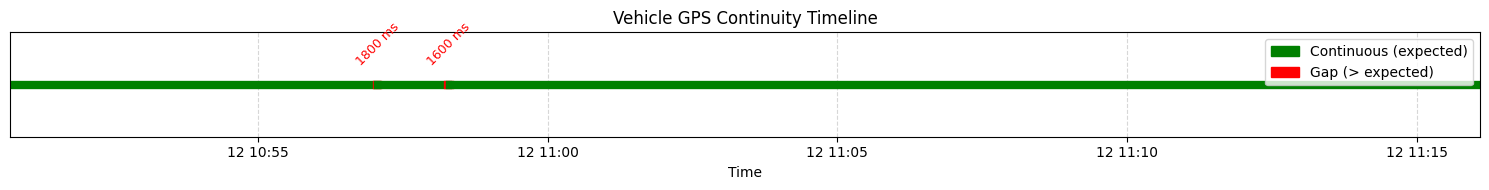


📦 Final Cleaned DataFrames Summary
Using nodes: [1, 2, 3, 4, 5, 7, 8, 9, 10]
Dropped nodes: [6]
Local projected CRS: EPSG:32618
gdf_cleaned: 7598 rows, columns: ['rpi1', 'rpi2', 'rpi3', 'rpi4', 'rpi5', 'rpi7', 'rpi8', 'rpi9', 'rpi10', 'geometry', 'distance_to_1', 'distance_to_2', 'distance_to_3', 'distance_to_4', 'distance_to_5', 'distance_to_7', 'distance_to_8', 'distance_to_9', 'distance_to_10']
normalized_cleaned: 7598 rows, columns: ['rpi1', 'rpi2', 'rpi3', 'rpi4', 'rpi5', 'rpi7', 'rpi8', 'rpi9', 'rpi10', 'Latitude', 'Longitude', 'distance_to_1', 'distance_to_2', 'distance_to_3', 'distance_to_4', 'distance_to_5', 'distance_to_7', 'distance_to_8', 'distance_to_9', 'distance_to_10']

✅ Valid time indices: 7473 out of 7598 total
First 10 valid indices: [61, 62, 63, 64, 65, 66, 67, 68, 69, 70]

=== Sanity checks ===
gdf_cleaned shape: (7598, 19)
normalized_cleaned shape: (7598, 20)
gdf_nodes shape: (9, 5)
num valid_indices: 7473
first 10 valid_indices: [61, 62, 63, 64, 65, 66, 67, 68,

,node,rows,rss_mean_db,rss_std_db,dist_mean_m,corr_rssi_logdist
0,1,7598,51.346497,6.720826,31.834233,-0.717834
1,2,7598,52.725864,7.429672,27.807666,-0.859250
2,3,7598,49.861221,7.231398,28.482468,-0.782619
3,4,7598,50.435837,4.936367,35.473038,-0.644415
4,5,7598,53.194828,5.833317,32.686417,-0.840937
5,7,7598,52.487495,4.522201,30.936937,-0.843171
6,8,7598,49.472500,5.557532,31.202846,-0.854367
7,9,7598,45.244522,8.430805,40.979794,-0.832723
8,10,7598,48.512157,6.380071,43.655583,-0.739060



=== Head of cleaned data ===


,rpi1,rpi2,rpi3,rpi4,rpi5,rpi7,rpi8,rpi9,rpi10,geometry,distance_to_1,distance_to_2,distance_to_3,distance_to_4,distance_to_5,distance_to_7,distance_to_8,distance_to_9,distance_to_10
datetime,,,,,,,,,,,,,,,,,,,
2025-08-12 10:50:43.200,43.445400,44.123062,41.126652,49.630707,46.481709,48.688774,47.938938,43.521324,40.603233,POINT (384143.669 4356622.344),59.650629,47.940491,37.437128,20.786139,42.780280,52.730310,60.708636,74.893078,81.771073
2025-08-12 10:50:43.400,42.865402,39.572495,42.362968,47.287933,47.614372,49.732292,43.902771,45.601620,38.006409,POINT (384143.67 4356622.345),59.651812,47.941716,37.438353,20.787375,42.781248,52.731537,60.709871,74.894302,81.772306
2025-08-12 10:50:43.600,43.462921,44.139351,41.358772,47.468357,47.478386,49.537773,43.273121,44.078995,37.388950,POINT (384143.67 4356622.345),59.651554,47.941498,37.438134,20.787186,42.780925,52.731398,60.709673,74.894168,81.772102
2025-08-12 10:50:43.800,43.814564,44.314713,40.645618,47.835808,47.618999,49.495544,44.241482,33.783623,36.781944,POINT (384143.67 4356622.345),59.651890,47.941818,37.438454,20.787491,42.781265,52.731672,60.709982,74.894439,81.772415
2025-08-12 10:50:44.000,43.052006,41.765579,41.098129,46.930164,47.106705,49.171288,49.058743,32.500286,42.921867,POINT (384143.67 4356622.345),59.651731,47.941690,37.438326,20.787383,42.781053,52.731602,60.709869,74.894372,81.772297


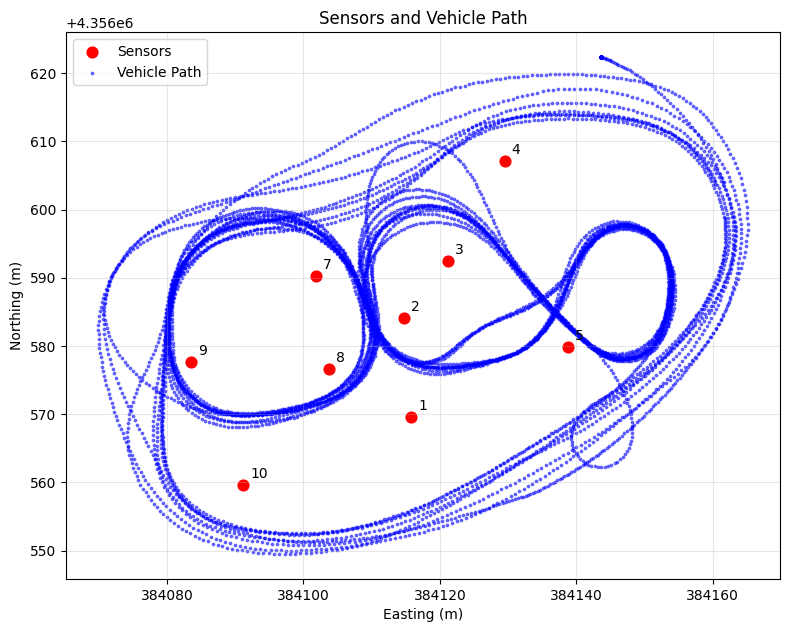

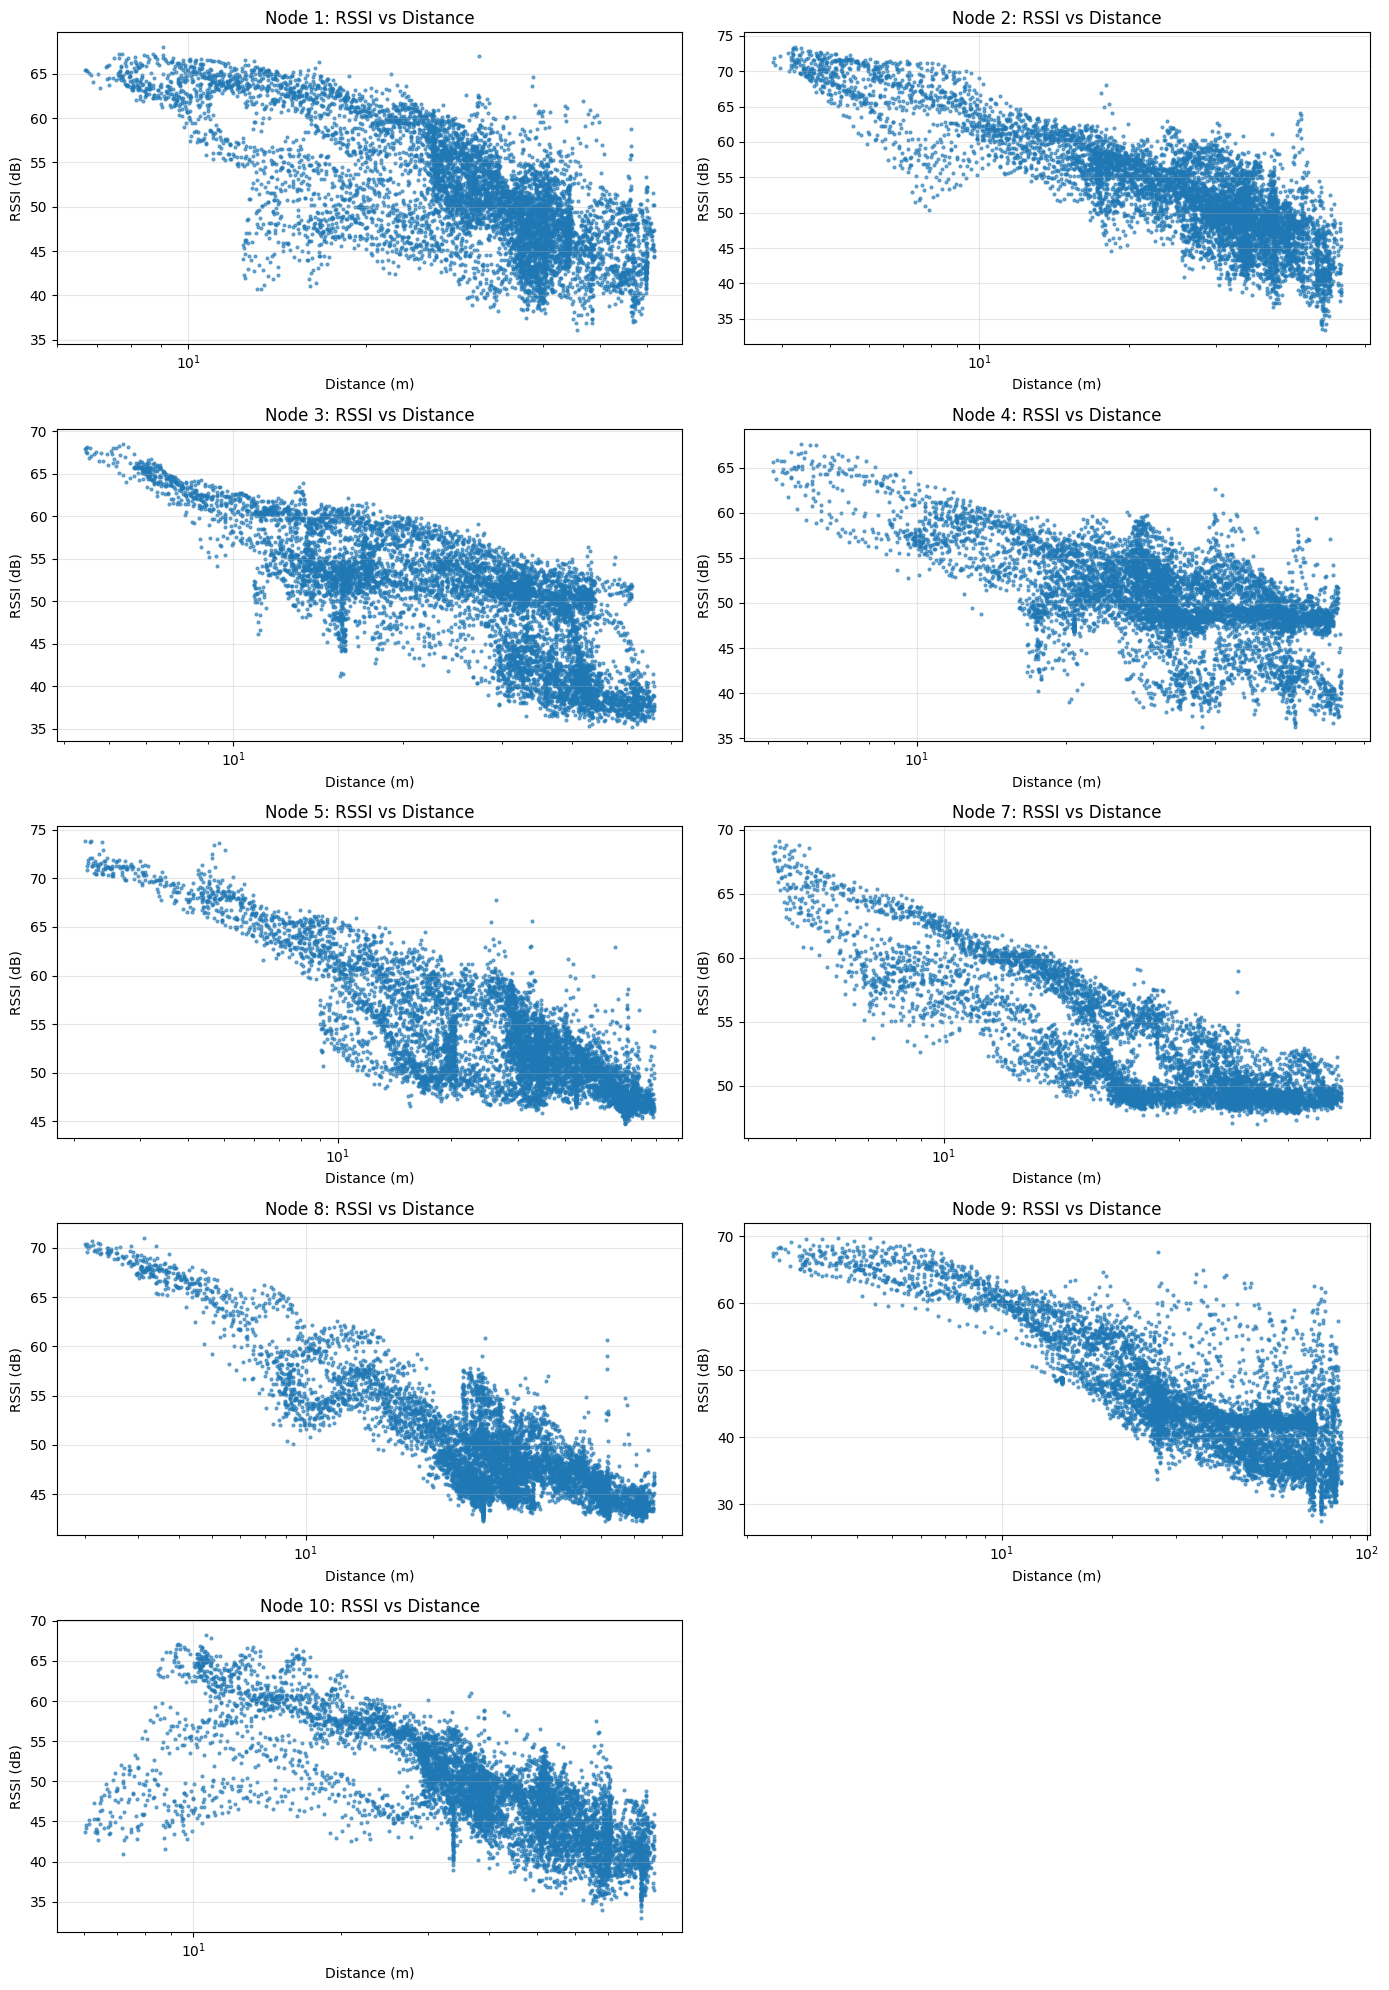


=== Saved outputs ===
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\gdf_cleaned.parquet
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\normalized_cleaned.parquet
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\data\processed\valid_indices.csv

✅ Extraction and processing completed successfully.


In [6]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Paths / import setup
# =========================
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from dataloader import load_data, plot_sensor_map, plot_rssi_vs_distance

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "20250812_1050"
SENSOR_LOC_FILE = PROJECT_ROOT / "data" / "nodes_gps.csv"

csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.lower().endswith(".csv")])
if not csv_files:
    raise FileNotFoundError(f"No GPS CSV files found in {DATA_DIR}")

VEHICLE_GPS_FILE = DATA_DIR / csv_files[0]

FLAC_NODES = [1,2,3,4,5,6,7,8,9,10]
DROP_NODES = [6]

CHUNK_MS = 10
SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"

print("=== Loading data ===")
print("DATA_DIR:", DATA_DIR)
print("SENSOR_LOC_FILE:", SENSOR_LOC_FILE)
print("VEHICLE_GPS_FILE:", VEHICLE_GPS_FILE)
print("KEEP_NODES:", [n for n in FLAC_NODES if n not in DROP_NODES])
print("DROP_NODES:", DROP_NODES)

# =========================
# Load / process
# =========================
gdf_cleaned, normalized_cleaned, valid_indices, gdf_nodes = load_data(
    data_dir=str(DATA_DIR),
    sensor_csv=str(SENSOR_LOC_FILE),
    gps_csv=str(VEHICLE_GPS_FILE),
    node_list=FLAC_NODES,
    chunk_ms=CHUNK_MS,
    sample_ms=SAMPLE_MS,
    resample_rate=RESAMPLE_RATE,
    drop_nodes=DROP_NODES,
)

# =========================
# Confirmation / sanity checks
# =========================
kept_nodes = [n for n in FLAC_NODES if n not in DROP_NODES]
rss_cols = [f"rpi{n}" for n in kept_nodes]
dist_cols = [f"distance_to_{n}" for n in kept_nodes]

missing_rss = [c for c in rss_cols if c not in gdf_cleaned.columns]
missing_dist = [c for c in dist_cols if c not in gdf_cleaned.columns]

print("\n=== Sanity checks ===")
print("gdf_cleaned shape:", gdf_cleaned.shape)
print("normalized_cleaned shape:", normalized_cleaned.shape)
print("gdf_nodes shape:", gdf_nodes.shape)
print("num valid_indices:", len(valid_indices))
print("first 10 valid_indices:", valid_indices[:10])
print("missing RSS cols:", missing_rss)
print("missing distance cols:", missing_dist)
print("time range:", gdf_cleaned.index.min(), "->", gdf_cleaned.index.max())
print("duplicate timestamps in gdf_cleaned:", gdf_cleaned.index.duplicated().sum())

summary_rows = []
for n in kept_nodes:
    rss_col = f"rpi{n}"
    dist_col = f"distance_to_{n}"
    if rss_col in gdf_cleaned.columns and dist_col in gdf_cleaned.columns:
        sub = gdf_cleaned[[rss_col, dist_col]].dropna()
        summary_rows.append({
            "node": n,
            "rows": len(sub),
            "rss_mean_db": sub[rss_col].mean(),
            "rss_std_db": sub[rss_col].std(),
            "dist_mean_m": sub[dist_col].mean(),
            "corr_rssi_logdist": sub[rss_col].corr(np.log10(sub[dist_col].clip(lower=1e-6)))
        })

summary_df = pd.DataFrame(summary_rows).sort_values("node")
display(summary_df)

print("\n=== Head of cleaned data ===")
display(gdf_cleaned.head())

# =========================
# Quick visuals
# =========================
plot_sensor_map(
    gdf_nodes=gdf_nodes,
    gdf_cleaned=gdf_cleaned,
    title="Sensors and Vehicle Path"
)

plot_rssi_vs_distance(
    gdf_cleaned=gdf_cleaned,
    node_list=kept_nodes,
    ncols=2,
)

# =========================
# Optional save for downstream
# =========================
OUT_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

gdf_cleaned.drop(columns="geometry").to_parquet(OUT_DIR / "gdf_cleaned.parquet")
normalized_cleaned.to_parquet(OUT_DIR / "normalized_cleaned.parquet")
pd.Series(valid_indices, name="valid_index").to_csv(OUT_DIR / "valid_indices.csv", index=False)

print("\n=== Saved outputs ===")
print(OUT_DIR / "gdf_cleaned.parquet")
print(OUT_DIR / "normalized_cleaned.parquet")
print(OUT_DIR / "valid_indices.csv")

print("\n✅ Extraction and processing completed successfully.")

In [13]:
from bandit_dataloader import build_bandit_dataset

kept_nodes = [1, 2, 3, 4, 5, 7, 8, 9, 10]

bandit_data = build_bandit_dataset(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=kept_nodes,
    history_steps=5,          # 5 * 200ms = 1.0s history
    max_subset_size=3,
    trigger_prob_threshold=0.12,
    trigger_min_nodes=2,
    trigger_max_nodes=5,
    trigger_temperature=4.0,
)

node_feature_df = bandit_data["node_feature_df"]
sequence_df = bandit_data["sequence_df"]
examples_df = bandit_data["examples_df"]
meta = bandit_data["meta"]

print(meta)
display(sequence_df.head())
display(examples_df.head())

{'ordered_nodes': [1, 2, 3, 4, 5, 7, 8, 9, 10], 'history_steps': 5, 'max_subset_size': 3, 'trigger_prob_threshold': 0.12, 'trigger_min_nodes': 2, 'trigger_max_nodes': 5, 'trigger_temperature': 4.0, 'utility_second_weight': 0.3, 'rho': 10.316986163806751, 'context_dim': 85, 'action_raw_dim': 42, 'num_times': 7473, 'num_examples': 41708}


,datetime,context_vec,triggered_nodes,num_triggered,top1_node,num_actions
0,2025-08-12 10:50:55.400,"[41.92222213745117, 41.92222213745117, 0.0, 0....","(2, 4, 5, 7, 9)",5,5,25
1,2025-08-12 10:50:55.600,"[40.70366668701172, 41.312944412231445, 0.6092...","(3, 4, 5, 7)",4,5,14
2,2025-08-12 10:50:55.800,"[40.772071838378906, 41.1326535542806, 0.55900...","(3, 4, 5, 7)",4,5,14
3,2025-08-12 10:50:56.000,"[46.4881591796875, 42.471529960632324, 2.36899...","(4, 5, 7)",3,5,7
4,2025-08-12 10:50:56.200,"[45.85105895996094, 43.14743576049805, 2.51338...","(3, 4, 5, 7)",4,3,14


,datetime,subset,subset_str,subset_size,context_vec,action_raw_vec,utility,d1,d2,triggered_nodes,top1_node
0,2025-08-12 10:50:55.400,"(2,)",2,1,"[41.92222213745117, 41.92222213745117, 0.0, 0....","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",2.036994e-05,47.952238,NaN,"(2, 4, 5, 7, 9)",5
1,2025-08-12 10:50:55.400,"(4,)",4,1,"[41.92222213745117, 41.92222213745117, 0.0, 0....","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",1.309863e-01,20.801781,NaN,"(2, 4, 5, 7, 9)",5
2,2025-08-12 10:50:55.400,"(5,)",5,1,"[41.92222213745117, 41.92222213745117, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...",1.853487e-04,42.770774,NaN,"(2, 4, 5, 7, 9)",5
3,2025-08-12 10:50:55.400,"(7,)",7,1,"[41.92222213745117, 41.92222213745117, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, ...",2.103364e-06,52.751937,NaN,"(2, 4, 5, 7, 9)",5
4,2025-08-12 10:50:55.400,"(9,)",9,1,"[41.92222213745117, 41.92222213745117, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, ...",3.551727e-12,74.915226,NaN,"(2, 4, 5, 7, 9)",5


num sequence rows: 7473
num example rows: 41708
context dim: 85
action raw dim: 42

Triggered-node count distribution:


num_triggered
2    4559
3    2042
4     733
5     139
Name: count, dtype: int64


Num-actions distribution:


num_actions
3     4559
7     2042
14     733
25     139
Name: count, dtype: int64


Subset-size distribution:


subset_size
1    18871
2    16473
3     6364
Name: count, dtype: int64


Utility summary:


count    4.170800e+04
mean     3.424048e-01
std      3.284217e-01
min      6.457674e-15
25%      2.873486e-02
50%      2.432481e-01
75%      6.181888e-01
max      1.124657e+00
Name: utility, dtype: float64

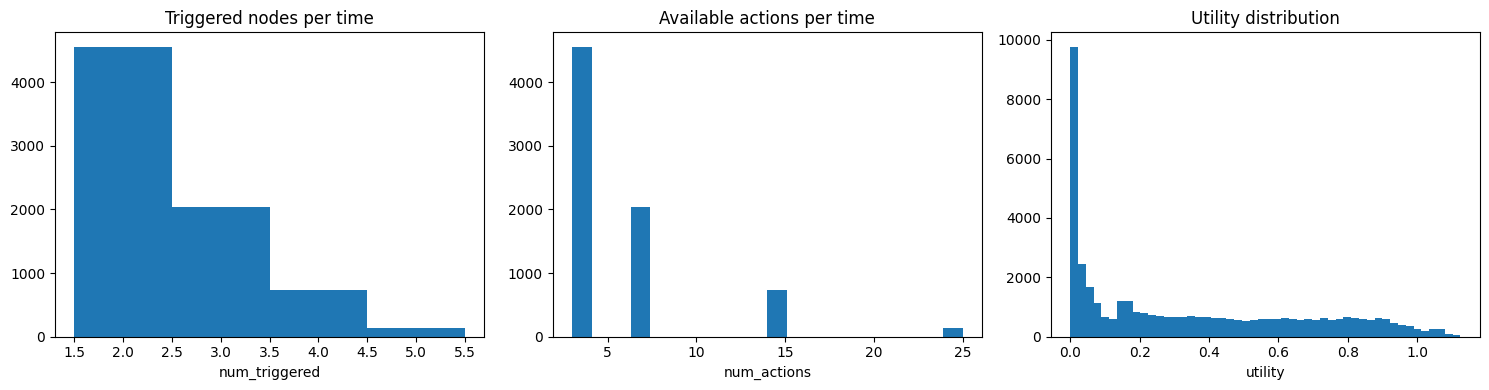


Split sizes by time:
train times: 4483
val times: 1494
test times: 1496

Split sizes by examples:
train examples: 26519
val examples: 7491
test examples: 7698

Raw linear baseline on [context_vec ; action_raw_vec]:
train | R2 = 0.7489 | RMSE = 0.151094
  val | R2 = 0.7585 | RMSE = 0.168556
 test | R2 = 0.7956 | RMSE = 0.154929

Per-time best-subset identification:
val  top-1 hit rate: 0.6439
test top-1 hit rate: 0.6604


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# ============================================================
# 1) Quick sanity checks
# ============================================================

print("num sequence rows:", len(sequence_df))
print("num example rows:", len(examples_df))
print("context dim:", meta["context_dim"])
print("action raw dim:", meta["action_raw_dim"])

print("\nTriggered-node count distribution:")
display(sequence_df["num_triggered"].value_counts().sort_index())

print("\nNum-actions distribution:")
display(sequence_df["num_actions"].value_counts().sort_index())

print("\nSubset-size distribution:")
display(examples_df["subset_size"].value_counts().sort_index())

print("\nUtility summary:")
display(examples_df["utility"].describe())

# Histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(sequence_df["num_triggered"], bins=np.arange(sequence_df["num_triggered"].min(), sequence_df["num_triggered"].max() + 2) - 0.5)
axes[0].set_title("Triggered nodes per time")
axes[0].set_xlabel("num_triggered")

axes[1].hist(sequence_df["num_actions"], bins=20)
axes[1].set_title("Available actions per time")
axes[1].set_xlabel("num_actions")

axes[2].hist(examples_df["utility"], bins=50)
axes[2].set_title("Utility distribution")
axes[2].set_xlabel("utility")

plt.tight_layout()
plt.show()

# ============================================================
# 2) Chronological split by TIME, not by rows
# ============================================================

unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)

n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)
n_test = n_times - n_train - n_val

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

print("\nSplit sizes by time:")
print("train times:", len(train_times))
print("val times:", len(val_times))
print("test times:", len(test_times))

print("\nSplit sizes by examples:")
print("train examples:", train_mask.sum())
print("val examples:", val_mask.sum())
print("test examples:", test_mask.sum())

# ============================================================
# 3) Build raw design matrix
#    First test: concat(context_vec, action_raw_vec)
# ============================================================

X = np.stack([
    np.concatenate([c, a])
    for c, a in zip(examples_df["context_vec"], examples_df["action_raw_vec"])
])

y = examples_df["utility"].to_numpy(dtype=float)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# ============================================================
# 4) Simple linear baseline
# ============================================================

lin_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

lin_model.fit(X_train, y_train)

pred_train = lin_model.predict(X_train)
pred_val = lin_model.predict(X_val)
pred_test = lin_model.predict(X_test)

def reg_report(name, y_true, y_pred):
    print(
        f"{name:>5} | "
        f"R2 = {r2_score(y_true, y_pred):.4f} | "
        f"RMSE = {np.sqrt(mean_squared_error(y_true, y_pred)):.6f}"
    )

print("\nRaw linear baseline on [context_vec ; action_raw_vec]:")
reg_report("train", y_train, pred_train)
reg_report("val", y_val, pred_val)
reg_report("test", y_test, pred_test)

# ============================================================
# 5) Per-time ranking sanity check
#    Can the linear model rank actions within a time step?
# ============================================================

def mean_top1_hit_rate(df, preds):
    tmp = df.copy()
    tmp["pred"] = preds
    hits = []

    for _, g in tmp.groupby("datetime"):
        best_true_idx = g["utility"].idxmax()
        best_pred_idx = g["pred"].idxmax()
        hits.append(float(best_true_idx == best_pred_idx))

    return np.mean(hits)

val_hit = mean_top1_hit_rate(examples_df[val_mask], pred_val)
test_hit = mean_top1_hit_rate(examples_df[test_mask], pred_test)

print("\nPer-time best-subset identification:")
print(f"val  top-1 hit rate: {val_hit:.4f}")
print(f"test top-1 hit rate: {test_hit:.4f}")

In [18]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# ============================================================
# 0) Reproducibility
# ============================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

# ============================================================
# 1) Chronological split by time
# ============================================================

unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)

n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)
n_test = n_times - n_train - n_val

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

# ============================================================
# 2) Build arrays
# ============================================================

C = np.stack(examples_df["context_vec"].to_numpy())          # context tower input
A = np.stack(examples_df["action_raw_vec"].to_numpy())       # action tower input
y = examples_df["utility"].to_numpy(dtype=np.float32)
times = examples_df["datetime"].to_numpy()

context_dim = C.shape[1]
action_dim = A.shape[1]

print("context_dim:", context_dim)
print("action_dim:", action_dim)
print("train/val/test examples:", train_mask.sum(), val_mask.sum(), test_mask.sum())

C_train, A_train, y_train = C[train_mask], A[train_mask], y[train_mask]
C_val, A_val, y_val = C[val_mask], A[val_mask], y[val_mask]
C_test, A_test, y_test = C[test_mask], A[test_mask], y[test_mask]

times_train = times[train_mask]
times_val = times[val_mask]
times_test = times[test_mask]

# ============================================================
# 3) Standardize using train split only
# ============================================================

def fit_standardizer(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma < 1e-8] = 1.0
    return mu, sigma

def apply_standardizer(X, mu, sigma):
    return (X - mu) / sigma

C_mu, C_sigma = fit_standardizer(C_train)
A_mu, A_sigma = fit_standardizer(A_train)

C_train_std = apply_standardizer(C_train, C_mu, C_sigma).astype(np.float32)
C_val_std = apply_standardizer(C_val, C_mu, C_sigma).astype(np.float32)
C_test_std = apply_standardizer(C_test, C_mu, C_sigma).astype(np.float32)

A_train_std = apply_standardizer(A_train, A_mu, A_sigma).astype(np.float32)
A_val_std = apply_standardizer(A_val, A_mu, A_sigma).astype(np.float32)
A_test_std = apply_standardizer(A_test, A_mu, A_sigma).astype(np.float32)

# For later full-dataset embedding extraction
C_full_std = apply_standardizer(C, C_mu, C_sigma).astype(np.float32)
A_full_std = apply_standardizer(A, A_mu, A_sigma).astype(np.float32)

# ============================================================
# 4) Dataset / loaders
# ============================================================

class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr)
        self.A_arr = torch.from_numpy(A_arr)
        self.y_arr = torch.from_numpy(y_arr)

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

train_ds = PairDataset(C_train_std, A_train_std, y_train)
val_ds = PairDataset(C_val_std, A_val_std, y_val)
test_ds = PairDataset(C_test_std, A_test_std, y_test)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

# ============================================================
# 5) Model
# ============================================================

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=64, emb_dim=16):
        super().__init__()

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        rep_dim = emb_dim * 4
        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        z = torch.cat([c, a, c * a, torch.abs(c - a)], dim=1)
        return z

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        out = self.head(z).squeeze(-1)
        return out

model = TwoTowerMLP(context_dim=context_dim, action_dim=action_dim, hidden=64, emb_dim=16).to(DEVICE)
print(model)

# ============================================================
# 6) Helpers
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def top1_hit_rate(times_arr, y_true, y_pred):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "y_pred": y_pred,
    })

    hits = []
    for _, g in df.groupby("datetime", sort=False):
        idx_true = g["y_true"].idxmax()
        idx_pred = g["y_pred"].idxmax()
        hits.append(float(idx_true == idx_pred))

    return float(np.mean(hits))

@torch.no_grad()
def predict_model(model, loader):
    model.eval()
    preds = []
    ys = []
    for C_batch, A_batch, y_batch in loader:
        C_batch = C_batch.to(DEVICE)
        A_batch = A_batch.to(DEVICE)
        pred = model(C_batch, A_batch).detach().cpu().numpy()
        preds.append(pred)
        ys.append(y_batch.numpy())
    return np.concatenate(preds), np.concatenate(ys)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=2048):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

# ============================================================
# 7) Train end-to-end neural regressor
# ============================================================

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()

best_state = None
best_val_rmse = np.inf
best_epoch = -1
patience = 8
epochs_without_improvement = 0
max_epochs = 40

history = []

for epoch in range(max_epochs):
    model.train()
    train_losses = []

    for C_batch, A_batch, y_batch in train_loader:
        C_batch = C_batch.to(DEVICE)
        A_batch = A_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(C_batch, A_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    # Evaluate on val
    pred_val_nn, y_val_nn = predict_model(model, val_loader)
    val_rmse = rmse(y_val_nn, pred_val_nn)
    val_r2 = r2_score(y_val_nn, pred_val_nn)
    val_hit = top1_hit_rate(times_val, y_val_nn, pred_val_nn)

    train_loss = float(np.mean(train_losses))
    history.append((epoch, train_loss, val_rmse, val_r2, val_hit))

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.5f} | "
        f"val_rmse={val_rmse:.5f} | "
        f"val_r2={val_r2:.4f} | "
        f"val_top1={val_hit:.4f}"
    )

    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

# Restore best model
model.load_state_dict(best_state)

# ============================================================
# 8) End-to-end neural fit evaluation
# ============================================================

pred_train_nn, y_train_nn = predict_model(model, train_loader)
pred_val_nn, y_val_nn = predict_model(model, val_loader)
pred_test_nn, y_test_nn = predict_model(model, test_loader)

print("\n=== End-to-end neural regressor ===")
for name, y_true, y_pred, t_arr in [
    ("train", y_train_nn, pred_train_nn, times_train),
    ("val",   y_val_nn,   pred_val_nn,   times_val),
    ("test",  y_test_nn,  pred_test_nn,  times_test),
]:
    print(
        f"{name:>5} | "
        f"R2 = {r2_score(y_true, y_pred):.4f} | "
        f"RMSE = {rmse(y_true, y_pred):.6f} | "
        f"top1 = {top1_hit_rate(t_arr, y_true, y_pred):.4f}"
    )

# ============================================================
# 9) Freeze embedding, then test linearity with Ridge
# ============================================================

Z_train = extract_embeddings(model, C_train_std, A_train_std)
Z_val = extract_embeddings(model, C_val_std, A_val_std)
Z_test = extract_embeddings(model, C_test_std, A_test_std)

alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
best_alpha = None
best_val_rmse_ridge = np.inf
best_ridge = None

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(Z_train, y_train)

    pred_val_ridge = ridge.predict(Z_val)
    cur_rmse = rmse(y_val, pred_val_ridge)

    if cur_rmse < best_val_rmse_ridge:
        best_val_rmse_ridge = cur_rmse
        best_alpha = alpha
        best_ridge = ridge

pred_train_ridge = best_ridge.predict(Z_train)
pred_val_ridge = best_ridge.predict(Z_val)
pred_test_ridge = best_ridge.predict(Z_test)

print("\n=== Linear fit on frozen learned embedding ===")
print("best alpha:", best_alpha)
for name, y_true, y_pred, t_arr in [
    ("train", y_train, pred_train_ridge, times_train),
    ("val",   y_val,   pred_val_ridge,   times_val),
    ("test",  y_test,  pred_test_ridge,  times_test),
]:
    print(
        f"{name:>5} | "
        f"R2 = {r2_score(y_true, y_pred):.4f} | "
        f"RMSE = {rmse(y_true, y_pred):.6f} | "
        f"top1 = {top1_hit_rate(t_arr, y_true, y_pred):.4f}"
    )

# ============================================================
# 10) Extract embedding for all examples for later bandit use
# ============================================================

Z_full = extract_embeddings(model, C_full_std, A_full_std)
print("\nFrozen embedding shape:", Z_full.shape)

# Optional: attach to dataframe for downstream use
examples_with_embed = examples_df.copy()
examples_with_embed["learned_embed"] = list(Z_full)

print("Saved learned embeddings into examples_with_embed['learned_embed']")

DEVICE: cuda
context_dim: 85
action_dim: 42
train/val/test examples: 26519 7491 7698
TwoTowerMLP(
  (context_tower): Sequential(
    (0): Linear(in_features=85, out_features=64, bias=True)
    (1): ReLU()
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=16, bias=True)
  )
  (action_tower): Sequential(
    (0): Linear(in_features=42, out_features=64, bias=True)
    (1): ReLU()
    (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=16, bias=True)
  )
  (head): Linear(in_features=64, out_features=1, bias=True)
)
Epoch 00 | train_loss=0.02104 | val_rmse=0.15367 | val_r2=0.7993 | val_top1=0.6118
Epoch 01 | train_loss=0.00780 | val_rmse=0.13831 | val_r2=0.8374 | val_top1=0.6452
Epoch 02 | train_loss=0.00552 | val_rmse=0.13259 | val_r2

In [20]:
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# ============================================================
# Assumes these already exist from previous cells:
#   C_train_std, A_train_std, y_train, times_train
#   C_val_std,   A_val_std,   y_val,   times_val
#   C_test_std,  A_test_std,  y_test,  times_test
#   context_dim, action_dim, DEVICE
# ============================================================

# ----------------------------
# Helpers
# ----------------------------
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    """
    Per-time decision metrics:
      - top1_hit
      - top3_hit
      - mean_rank_of_true_best
      - avg_utility_regret
      - avg_normalized_regret
    """
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))

        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

# ----------------------------
# Raw linear baseline
# ----------------------------
def fit_and_eval_raw_ridge():
    X_train = np.concatenate([C_train_std, A_train_std], axis=1)
    X_val = np.concatenate([C_val_std, A_val_std], axis=1)
    X_test = np.concatenate([C_test_std, A_test_std], axis=1)

    alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
    best = None
    best_key = (np.inf, np.inf)  # (val_regret, -val_top1)

    for alpha in alphas:
        ridge = Ridge(alpha=alpha)
        ridge.fit(X_train, y_train)
        pred_val = ridge.predict(X_val)
        dm_val = decision_metrics(times_val, y_val, pred_val)

        current_key = (dm_val["avg_utility_regret"], -dm_val["top1_hit"])
        if current_key < best_key:
            best_key = current_key
            best = (alpha, ridge)

    alpha, ridge = best
    out = {"model_name": "raw_linear", "alpha": alpha}

    for split_name, X, y, t in [
        ("train", X_train, y_train, times_train),
        ("val",   X_val,   y_val,   times_val),
        ("test",  X_test,  y_test,  times_test),
    ]:
        pred = ridge.predict(X)
        dm = decision_metrics(t, y, pred)
        out[f"{split_name}_r2"] = r2_score(y, pred)
        out[f"{split_name}_rmse"] = rmse(y, pred)
        out[f"{split_name}_top1"] = dm["top1_hit"]
        out[f"{split_name}_top3"] = dm["top3_hit"]
        out[f"{split_name}_mean_rank"] = dm["mean_rank_true_best"]
        out[f"{split_name}_avg_regret"] = dm["avg_utility_regret"]
        out[f"{split_name}_avg_norm_regret"] = dm["avg_normalized_regret"]

    return out

# ----------------------------
# Dataset
# ----------------------------
class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr)
        self.A_arr = torch.from_numpy(A_arr)
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

train_ds = PairDataset(C_train_std, A_train_std, y_train)
val_ds   = PairDataset(C_val_std,   A_val_std,   y_val)
test_ds  = PairDataset(C_test_std,  A_test_std,  y_test)

# ----------------------------
# Model
# ----------------------------
class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=128, emb_dim=32, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "full":
            rep_dim = emb_dim * 4   # [c, a, c*a, |c-a|]
        elif combine_mode == "mul_only":
            rep_dim = emb_dim * 3   # [c, a, c*a]
        else:
            raise ValueError(f"Unsupported combine_mode: {combine_mode}")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        if self.combine_mode == "full":
            z = torch.cat([c, a, c * a, torch.abs(c - a)], dim=1)
        elif self.combine_mode == "mul_only":
            z = torch.cat([c, a, c * a], dim=1)
        return z

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=2048):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

# ----------------------------
# One learned config, one seed
# ----------------------------
def run_one_config(config, seed, max_epochs=50, patience=10):
    set_all_seeds(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=512,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )

    model = TwoTowerMLP(
        context_dim=context_dim,
        action_dim=action_dim,
        hidden=config["hidden"],
        emb_dim=config["emb_dim"],
        combine_mode=config["combine_mode"],
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    if config["loss_name"] == "huber":
        loss_fn = nn.SmoothL1Loss()
    elif config["loss_name"] == "mse":
        loss_fn = nn.MSELoss()
    else:
        raise ValueError(config["loss_name"])

    best_state = None
    best_epoch = -1
    best_alpha = None
    best_key = (np.inf, np.inf)   # (val_avg_regret, -val_top1)
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        for C_batch, A_batch, y_batch in train_loader:
            C_batch = C_batch.to(DEVICE)
            A_batch = A_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            pred = model(C_batch, A_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()

        # Select using frozen embedding + linear head
        Z_train = extract_embeddings(model, C_train_std, A_train_std)
        Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

        best_ridge_local = None
        best_alpha_local = None
        best_ridge_key_local = (np.inf, np.inf)

        for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
            ridge = Ridge(alpha=alpha)
            ridge.fit(Z_train, y_train)
            pred_val = ridge.predict(Z_val)
            dm_val = decision_metrics(times_val, y_val, pred_val)

            local_key = (dm_val["avg_utility_regret"], -dm_val["top1_hit"])
            if local_key < best_ridge_key_local:
                best_ridge_key_local = local_key
                best_alpha_local = alpha
                best_ridge_local = ridge

        current_key = best_ridge_key_local

        if current_key < best_key:
            best_key = current_key
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_alpha = best_alpha_local
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break

    model.load_state_dict(best_state)

    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
    Z_test  = extract_embeddings(model, C_test_std,  A_test_std)

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(Z_train, y_train)

    result = {
        "config_name": config["name"],
        "seed": seed,
        "best_epoch": best_epoch,
        "best_alpha": best_alpha,
    }

    for split_name, Z, y, t in [
        ("train", Z_train, y_train, times_train),
        ("val",   Z_val,   y_val,   times_val),
        ("test",  Z_test,  y_test,  times_test),
    ]:
        pred = ridge.predict(Z)
        dm = decision_metrics(t, y, pred)

        result[f"{split_name}_r2"] = r2_score(y, pred)
        result[f"{split_name}_rmse"] = rmse(y, pred)
        result[f"{split_name}_top1"] = dm["top1_hit"]
        result[f"{split_name}_top3"] = dm["top3_hit"]
        result[f"{split_name}_mean_rank"] = dm["mean_rank_true_best"]
        result[f"{split_name}_avg_regret"] = dm["avg_utility_regret"]
        result[f"{split_name}_avg_norm_regret"] = dm["avg_normalized_regret"]

    return result

# ============================================================
# 1) Baseline
# ============================================================
baseline_result = fit_and_eval_raw_ridge()
baseline_df = pd.DataFrame([baseline_result])
print("=== Raw linear baseline ===")
display(baseline_df)

# ============================================================
# 2) Only the 3 sensible learned candidates
# ============================================================
candidate_configs = [
    {
        "name": "decision_first",
        "hidden": 128,
        "emb_dim": 8,
        "loss_name": "mse",
        "combine_mode": "mul_only",
    },
    {
        "name": "linearity_first",
        "hidden": 128,
        "emb_dim": 32,
        "loss_name": "huber",
        "combine_mode": "full",
    },
    {
        "name": "robust_mul_only",
        "hidden": 128,
        "emb_dim": 32,
        "loss_name": "huber",
        "combine_mode": "mul_only",
    },
]

seeds = [11, 22, 33]

# ============================================================
# 3) Run candidates
# ============================================================
all_results = []

for cfg in candidate_configs:
    print(f"\n=== Running config: {cfg['name']} ===")
    for seed in seeds:
        print(f"  seed={seed}")
        res = run_one_config(cfg, seed, max_epochs=50, patience=10)
        print(
            f"    best_epoch={res['best_epoch']}, alpha={res['best_alpha']} | "
            f"val_regret={res['val_avg_regret']:.4f}, "
            f"val_top1={res['val_top1']:.4f}, "
            f"test_regret={res['test_avg_regret']:.4f}, "
            f"test_top1={res['test_top1']:.4f}"
        )
        all_results.append(res)

results_df = pd.DataFrame(all_results)

print("\n=== Per-run results ===")
display(results_df.sort_values(["config_name", "seed"]))

# ============================================================
# 4) Aggregate across seeds
# ============================================================
agg_df = results_df.groupby("config_name").agg(
    val_avg_regret_mean=("val_avg_regret", "mean"),
    val_avg_regret_std=("val_avg_regret", "std"),
    val_avg_norm_regret_mean=("val_avg_norm_regret", "mean"),
    val_top1_mean=("val_top1", "mean"),
    val_top1_std=("val_top1", "std"),
    val_top3_mean=("val_top3", "mean"),
    val_rmse_mean=("val_rmse", "mean"),
    val_r2_mean=("val_r2", "mean"),
    val_mean_rank_mean=("val_mean_rank", "mean"),

    test_avg_regret_mean=("test_avg_regret", "mean"),
    test_avg_regret_std=("test_avg_regret", "std"),
    test_avg_norm_regret_mean=("test_avg_norm_regret", "mean"),
    test_top1_mean=("test_top1", "mean"),
    test_top1_std=("test_top1", "std"),
    test_top3_mean=("test_top3", "mean"),
    test_rmse_mean=("test_rmse", "mean"),
    test_r2_mean=("test_r2", "mean"),
    test_mean_rank_mean=("test_mean_rank", "mean"),
).reset_index()

agg_df = agg_df.sort_values(
    by=["val_avg_regret_mean", "val_top1_mean"],
    ascending=[True, False],
).reset_index(drop=True)

print("\n=== Aggregated results across seeds (ranked by validation regret, then top1) ===")
display(agg_df)

# ============================================================
# 5) Easy side-by-side with raw baseline
# ============================================================
baseline_compare = pd.DataFrame([{
    "config_name": "raw_linear_baseline",
    "val_avg_regret_mean": baseline_result["val_avg_regret"],
    "val_avg_norm_regret_mean": baseline_result["val_avg_norm_regret"],
    "val_top1_mean": baseline_result["val_top1"],
    "val_top3_mean": baseline_result["val_top3"],
    "val_rmse_mean": baseline_result["val_rmse"],
    "val_r2_mean": baseline_result["val_r2"],
    "test_avg_regret_mean": baseline_result["test_avg_regret"],
    "test_avg_norm_regret_mean": baseline_result["test_avg_norm_regret"],
    "test_top1_mean": baseline_result["test_top1"],
    "test_top3_mean": baseline_result["test_top3"],
    "test_rmse_mean": baseline_result["test_rmse"],
    "test_r2_mean": baseline_result["test_r2"],
}])

compare_df = pd.concat([
    baseline_compare,
    agg_df[[
        "config_name",
        "val_avg_regret_mean",
        "val_avg_norm_regret_mean",
        "val_top1_mean",
        "val_top3_mean",
        "val_rmse_mean",
        "val_r2_mean",
        "test_avg_regret_mean",
        "test_avg_norm_regret_mean",
        "test_top1_mean",
        "test_top3_mean",
        "test_rmse_mean",
        "test_r2_mean",
    ]]
], ignore_index=True)

print("\n=== Baseline vs learned candidates ===")
display(compare_df)

C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.08906e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


=== Raw linear baseline ===


,model_name,alpha,train_r2,train_rmse,train_top1,train_top3,train_mean_rank,train_avg_regret,train_avg_norm_regret,val_r2,...,val_mean_rank,val_avg_regret,val_avg_norm_regret,test_r2,test_rmse,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,raw_linear,10.0,0.748757,0.151137,0.607629,0.923935,1.795673,0.004659,0.043709,0.758915,...,1.355422,0.002351,0.005385,0.7951,0.1551,0.864973,0.957219,1.426471,0.003992,0.008871



=== Running config: decision_first ===
  seed=11
    best_epoch=21, alpha=10.0 | val_regret=0.0017, val_top1=0.7497, test_regret=0.0022, test_top1=0.7741
  seed=22
    best_epoch=26, alpha=100.0 | val_regret=0.0009, val_top1=0.7825, test_regret=0.0010, test_top1=0.8048
  seed=33
    best_epoch=14, alpha=100.0 | val_regret=0.0014, val_top1=0.7617, test_regret=0.0023, test_top1=0.7988

=== Running config: linearity_first ===
  seed=11
    best_epoch=9, alpha=0.01 | val_regret=0.0013, val_top1=0.7557, test_regret=0.0024, test_top1=0.7914
  seed=22
    best_epoch=9, alpha=100.0 | val_regret=0.0020, val_top1=0.6995, test_regret=0.0029, test_top1=0.6918
  seed=33
    best_epoch=7, alpha=100.0 | val_regret=0.0029, val_top1=0.7550, test_regret=0.0058, test_top1=0.7801

=== Running config: robust_mul_only ===
  seed=11
    best_epoch=21, alpha=10.0 | val_regret=0.0012, val_top1=0.7617, test_regret=0.0022, test_top1=0.7781
  seed=22
    best_epoch=12, alpha=100.0 | val_regret=0.0014, val_top1=0

,config_name,seed,best_epoch,best_alpha,train_r2,train_rmse,train_top1,train_top3,train_mean_rank,train_avg_regret,...,val_mean_rank,val_avg_regret,val_avg_norm_regret,test_r2,test_rmse,test_top1,test_top3,test_mean_rank,test_avg_regret,test_avg_norm_regret
0,decision_first,11,21,10.00,0.989442,0.030982,0.607406,0.901851,1.781619,0.001012,...,1.449130,0.001705,0.008751,0.911004,0.102218,0.774064,0.968583,1.446524,0.002166,0.007331
1,decision_first,22,26,100.00,0.985273,0.036591,0.693063,0.929735,1.593799,0.000377,...,1.369478,0.000884,0.001289,0.911105,0.102160,0.804813,0.970588,1.348930,0.001033,0.002734
2,decision_first,33,14,100.00,0.985022,0.036902,0.601829,0.898952,1.788981,0.000816,...,1.443106,0.001430,0.004075,0.909788,0.102913,0.798797,0.954545,1.472594,0.002340,0.006646
3,linearity_first,11,9,0.01,0.982856,0.039480,0.600268,0.896498,1.806603,0.001136,...,1.431727,0.001332,0.003179,0.919299,0.097337,0.791444,0.965241,1.399733,0.002365,0.008309
4,linearity_first,22,9,100.00,0.980270,0.042353,0.612313,0.886460,1.893598,0.001435,...,1.552209,0.001972,0.006197,0.910537,0.102486,0.691845,0.953877,1.554813,0.002925,0.005566
5,linearity_first,33,7,100.00,0.979503,0.043168,0.594691,0.894936,1.843185,0.001184,...,1.473226,0.002854,0.010097,0.906184,0.104949,0.780080,0.942513,1.530749,0.005831,0.024825
6,robust_mul_only,11,21,10.00,0.988734,0.032004,0.596029,0.903636,1.757975,0.001034,...,1.405622,0.001225,0.003806,0.918419,0.097867,0.778075,0.971925,1.406417,0.002229,0.006764
7,robust_mul_only,22,12,100.00,0.979162,0.043526,0.609636,0.902075,1.788088,0.001151,...,1.450469,0.001383,0.003842,0.905472,0.105347,0.740642,0.962567,1.435829,0.001806,0.004497
8,robust_mul_only,33,17,100.00,0.982298,0.040118,0.672764,0.917243,1.663618,0.000592,...,1.388220,0.001965,0.004038,0.923859,0.094547,0.810829,0.967246,1.409759,0.002225,0.006135



=== Aggregated results across seeds (ranked by validation regret, then top1) ===


,config_name,val_avg_regret_mean,val_avg_regret_std,val_avg_norm_regret_mean,val_top1_mean,val_top1_std,val_top3_mean,val_rmse_mean,val_r2_mean,val_mean_rank_mean,test_avg_regret_mean,test_avg_regret_std,test_avg_norm_regret_mean,test_top1_mean,test_top1_std,test_top3_mean,test_rmse_mean,test_r2_mean,test_mean_rank_mean
0,decision_first,0.001339,0.000418,0.004705,0.764614,0.016590,0.953592,0.112012,0.893367,1.420571,0.001846,0.000710,0.005570,0.792558,0.016296,0.964572,0.102430,0.910632,1.422683
1,robust_mul_only,0.001524,0.000390,0.003895,0.755020,0.030016,0.960286,0.109825,0.897485,1.414770,0.002087,0.000243,0.005798,0.776515,0.035120,0.967246,0.099254,0.915917,1.417335
2,linearity_first,0.002053,0.000764,0.006491,0.736725,0.032270,0.942213,0.109896,0.897276,1.485721,0.003707,0.001861,0.012900,0.754456,0.054520,0.953877,0.101591,0.912006,1.495098



=== Baseline vs learned candidates ===


,config_name,val_avg_regret_mean,val_avg_norm_regret_mean,val_top1_mean,val_top3_mean,val_rmse_mean,val_r2_mean,test_avg_regret_mean,test_avg_norm_regret_mean,test_top1_mean,test_top3_mean,test_rmse_mean,test_r2_mean
0,raw_linear_baseline,0.002351,0.005385,0.846051,0.953146,0.168427,0.758915,0.003992,0.008871,0.864973,0.957219,0.155100,0.795100
1,decision_first,0.001339,0.004705,0.764614,0.953592,0.112012,0.893367,0.001846,0.005570,0.792558,0.964572,0.102430,0.910632
2,robust_mul_only,0.001524,0.003895,0.755020,0.960286,0.109825,0.897485,0.002087,0.005798,0.776515,0.967246,0.099254,0.915917
3,linearity_first,0.002053,0.006491,0.736725,0.942213,0.109896,0.897276,0.003707,0.012900,0.754456,0.953877,0.101591,0.912006


In [21]:
import os
import copy
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# ============================================================
# Final chosen config
# ============================================================
FINAL_CONFIG = {
    "name": "decision_first_final",
    "hidden": 128,
    "emb_dim": 8,
    "loss_name": "mse",
    "combine_mode": "mul_only",
    "seed": 22,
    "max_epochs": 50,
    "patience": 10,
    "ridge_alphas": [0.01, 0.1, 1.0, 10.0, 100.0],
}

print("FINAL_CONFIG =", FINAL_CONFIG)

# ============================================================
# Helpers
# ============================================================
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))
        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr)
        self.A_arr = torch.from_numpy(A_arr)
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=128, emb_dim=8, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "full":
            rep_dim = emb_dim * 4
        elif combine_mode == "mul_only":
            rep_dim = emb_dim * 3
        else:
            raise ValueError(f"Unsupported combine_mode: {combine_mode}")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        if self.combine_mode == "full":
            z = torch.cat([c, a, c * a, torch.abs(c - a)], dim=1)
        elif self.combine_mode == "mul_only":
            z = torch.cat([c, a, c * a], dim=1)
        return z

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=2048):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

# ============================================================
# Build loaders
# ============================================================
set_all_seeds(FINAL_CONFIG["seed"])

train_ds = PairDataset(C_train_std, A_train_std, y_train)
val_ds   = PairDataset(C_val_std,   A_val_std,   y_val)
test_ds  = PairDataset(C_test_std,  A_test_std,  y_test)

train_loader = DataLoader(
    train_ds,
    batch_size=512,
    shuffle=True,
    generator=torch.Generator().manual_seed(FINAL_CONFIG["seed"]),
)
val_loader = DataLoader(val_ds, batch_size=2048, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=2048, shuffle=False)

# ============================================================
# Train
# ============================================================
model = TwoTowerMLP(
    context_dim=context_dim,
    action_dim=action_dim,
    hidden=FINAL_CONFIG["hidden"],
    emb_dim=FINAL_CONFIG["emb_dim"],
    combine_mode=FINAL_CONFIG["combine_mode"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss() if FINAL_CONFIG["loss_name"] == "mse" else nn.SmoothL1Loss()

best_state = None
best_epoch = -1
best_alpha = None
best_key = (np.inf, np.inf)   # (val_avg_regret, -val_top1)
epochs_without_improvement = 0
history = []

for epoch in range(FINAL_CONFIG["max_epochs"]):
    model.train()
    train_losses = []

    for C_batch, A_batch, y_batch in train_loader:
        C_batch = C_batch.to(DEVICE)
        A_batch = A_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(C_batch, A_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Select checkpoint using frozen embedding + ridge
    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

    best_ridge_local = None
    best_alpha_local = None
    best_local_key = (np.inf, np.inf)

    for alpha in FINAL_CONFIG["ridge_alphas"]:
        ridge = Ridge(alpha=alpha)
        ridge.fit(Z_train, y_train)
        pred_val = ridge.predict(Z_val)
        dm_val = decision_metrics(times_val, y_val, pred_val)
        local_key = (dm_val["avg_utility_regret"], -dm_val["top1_hit"])
        if local_key < best_local_key:
            best_local_key = local_key
            best_alpha_local = alpha
            best_ridge_local = ridge

    current_key = best_local_key
    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "val_avg_regret": best_local_key[0],
        "val_top1": -best_local_key[1],
        "best_alpha_local": best_alpha_local,
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={np.mean(train_losses):.6f} | "
        f"val_regret={best_local_key[0]:.6f} | "
        f"val_top1={-best_local_key[1]:.4f} | "
        f"alpha={best_alpha_local}"
    )

    if current_key < best_key:
        best_key = current_key
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        best_alpha = best_alpha_local
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= FINAL_CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

# Restore best checkpoint
model.load_state_dict(best_state)

# ============================================================
# Final frozen embedding + ridge fit
# ============================================================
Z_train = extract_embeddings(model, C_train_std, A_train_std)
Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
Z_test  = extract_embeddings(model, C_test_std,  A_test_std)
Z_full  = extract_embeddings(model, C_full_std,  A_full_std)

ridge = Ridge(alpha=best_alpha)
ridge.fit(Z_train, y_train)

def eval_split(name, Z, y, t):
    pred = ridge.predict(Z)
    dm = decision_metrics(t, y, pred)
    print(
        f"{name:>5} | "
        f"R2={r2_score(y, pred):.4f} | "
        f"RMSE={rmse(y, pred):.6f} | "
        f"top1={dm['top1_hit']:.4f} | "
        f"top3={dm['top3_hit']:.4f} | "
        f"mean_rank={dm['mean_rank_true_best']:.4f} | "
        f"avg_regret={dm['avg_utility_regret']:.6f} | "
        f"avg_norm_regret={dm['avg_normalized_regret']:.6f}"
    )
    return pred, dm

print("\n=== Final frozen embedding linear-fit metrics ===")
pred_train, dm_train = eval_split("train", Z_train, y_train, times_train)
pred_val,   dm_val   = eval_split("val",   Z_val,   y_val,   times_val)
pred_test,  dm_test  = eval_split("test",  Z_test,  y_test,  times_test)

print("\nBest epoch:", best_epoch)
print("Best ridge alpha:", best_alpha)
print("Frozen embedding shape:", Z_full.shape)

# ============================================================
# Save artifacts
# ============================================================
OUT_DIR = PROJECT_ROOT / "results" / "final_embedding_decision_first"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Save torch checkpoint
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": FINAL_CONFIG,
        "context_dim": int(context_dim),
        "action_dim": int(action_dim),
        "best_epoch": int(best_epoch),
        "best_alpha": float(best_alpha),
        "history": history,
    },
    OUT_DIR / "two_tower_model.pt"
)

# Save ridge + standardizers + metadata
with open(OUT_DIR / "ridge_model.pkl", "wb") as f:
    pickle.dump(ridge, f)

with open(OUT_DIR / "standardizers.pkl", "wb") as f:
    pickle.dump(
        {
            "C_mu": C_mu,
            "C_sigma": C_sigma,
            "A_mu": A_mu,
            "A_sigma": A_sigma,
        },
        f
    )

with open(OUT_DIR / "meta.json", "w") as f:
    json.dump(
        {
            "config": FINAL_CONFIG,
            "best_epoch": int(best_epoch),
            "best_alpha": float(best_alpha),
            "metrics": {
                "train": {
                    "r2": float(r2_score(y_train, pred_train)),
                    "rmse": float(rmse(y_train, pred_train)),
                    "top1": float(dm_train["top1_hit"]),
                    "top3": float(dm_train["top3_hit"]),
                    "mean_rank": float(dm_train["mean_rank_true_best"]),
                    "avg_regret": float(dm_train["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_train["avg_normalized_regret"]),
                },
                "val": {
                    "r2": float(r2_score(y_val, pred_val)),
                    "rmse": float(rmse(y_val, pred_val)),
                    "top1": float(dm_val["top1_hit"]),
                    "top3": float(dm_val["top3_hit"]),
                    "mean_rank": float(dm_val["mean_rank_true_best"]),
                    "avg_regret": float(dm_val["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_val["avg_normalized_regret"]),
                },
                "test": {
                    "r2": float(r2_score(y_test, pred_test)),
                    "rmse": float(rmse(y_test, pred_test)),
                    "top1": float(dm_test["top1_hit"]),
                    "top3": float(dm_test["top3_hit"]),
                    "mean_rank": float(dm_test["mean_rank_true_best"]),
                    "avg_regret": float(dm_test["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_test["avg_normalized_regret"]),
                },
            },
        },
        f,
        indent=2
    )

# Save embeddings + dataframe
np.save(OUT_DIR / "learned_embeddings.npy", Z_full)

examples_with_embed = examples_df.copy()
examples_with_embed["learned_embed"] = list(Z_full)
examples_with_embed.to_pickle(OUT_DIR / "examples_with_embed.pkl")

print("\nSaved artifacts to:")
print(OUT_DIR / "two_tower_model.pt")
print(OUT_DIR / "ridge_model.pkl")
print(OUT_DIR / "standardizers.pkl")
print(OUT_DIR / "meta.json")
print(OUT_DIR / "learned_embeddings.npy")
print(OUT_DIR / "examples_with_embed.pkl")

FINAL_CONFIG = {'name': 'decision_first_final', 'hidden': 128, 'emb_dim': 8, 'loss_name': 'mse', 'combine_mode': 'mul_only', 'seed': 22, 'max_epochs': 50, 'patience': 10, 'ridge_alphas': [0.01, 0.1, 1.0, 10.0, 100.0]}
Epoch 00 | train_loss=0.029925 | val_regret=0.005230 | val_top1=0.7584 | alpha=0.01
Epoch 01 | train_loss=0.011618 | val_regret=0.005032 | val_top1=0.7162 | alpha=100.0
Epoch 02 | train_loss=0.006981 | val_regret=0.005483 | val_top1=0.6948 | alpha=100.0
Epoch 03 | train_loss=0.004912 | val_regret=0.005543 | val_top1=0.7062 | alpha=100.0
Epoch 04 | train_loss=0.003794 | val_regret=0.004931 | val_top1=0.7088 | alpha=100.0
Epoch 05 | train_loss=0.003036 | val_regret=0.004390 | val_top1=0.6961 | alpha=100.0
Epoch 06 | train_loss=0.002497 | val_regret=0.005276 | val_top1=0.6874 | alpha=100.0
Epoch 07 | train_loss=0.002183 | val_regret=0.004735 | val_top1=0.7088 | alpha=100.0
Epoch 08 | train_loss=0.001902 | val_regret=0.004715 | val_top1=0.6995 | alpha=100.0
Epoch 09 | train_l

In [28]:
import importlib
import bandit_dataloader_simple
importlib.reload(bandit_dataloader_simple)

from bandit_dataloader_simple import build_bandit_dataset_simple

bandit_data = build_bandit_dataset_simple(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=[1, 2, 3, 4, 5, 7, 8, 9, 10],
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=0.35,
    utility_third_weight=0.10,
    verbose=True,
    progress_every=500,
)

node_feature_df = bandit_data["node_feature_df"]
sequence_df = bandit_data["sequence_df"]
examples_df = bandit_data["examples_df"]
meta = bandit_data["meta"]

print("num_actions_per_time:", meta["num_actions_per_time"])
print("num_times:", meta["num_times"])
print("num_examples:", meta["num_examples"])
print("context_dim:", meta["context_dim"])
print("action_raw_dim:", meta["action_raw_dim"])

eps_list = [0.0, 1e-4, 1e-3, 5e-3]
rows = []
for dt, g in examples_df.groupby("datetime", sort=False):
    u = g["utility"].to_numpy()
    u_max = u.max()
    for eps in eps_list:
        rows.append({
            "datetime": dt,
            "eps": eps,
            "count_near_opt": int(np.sum(u >= u_max - eps)),
        })

tie_df = pd.DataFrame(rows)
display(tie_df.groupby("eps")["count_near_opt"].agg(["mean", "median", "max"]))

[1/8] Restricting to valid sequential chain...
      valid timesteps: 7473
      kept nodes: [1, 2, 3, 4, 5, 7, 8, 9, 10]
[2/8] Loading sensor coordinates and normalizing geometry...
[3/8] Extracting per-time RSSI and distance arrays...
[4/8] Choosing utility scale rho...
      rho = 10.3170
[5/8] Precomputing full subset universe and static subset geometry...
      num actions per time = 129
[6/8] Building per-node temporal features...
      temporal features: 1/7473
      temporal features: 500/7473
      temporal features: 1000/7473
      temporal features: 1500/7473
      temporal features: 2000/7473
      temporal features: 2500/7473
      temporal features: 3000/7473
      temporal features: 3500/7473
      temporal features: 4000/7473
      temporal features: 4500/7473
      temporal features: 5000/7473
      temporal features: 5500/7473
      temporal features: 6000/7473
      temporal features: 6500/7473
      temporal features: 7000/7473
      temporal features: 7473/7473
[7/

,mean,median,max
eps,,,
0.0000,1.000000,1.0,1
0.0001,1.536465,1.0,15
0.0010,4.385923,1.0,37
0.0050,9.477987,3.0,129


In [29]:
import copy
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

FINAL_CONFIG = {
    "name": "full_universe_decision_first_v2",
    "hidden": 128,
    "emb_dim": 8,
    "loss_name": "mse",
    "combine_mode": "mul_only",
    "seed": 22,
    "max_epochs": 80,
    "patience": 20,
    "ridge_alphas": [0.01, 0.1, 1.0, 10.0, 100.0],
}

print("FINAL_CONFIG =", FINAL_CONFIG)
print("DEVICE =", DEVICE)

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))

        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

# chronological split
unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)
n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

C = np.stack(examples_df["context_vec"].to_numpy()).astype(np.float32)
A = np.stack(examples_df["action_raw_vec"].to_numpy()).astype(np.float32)
y = examples_df["utility"].to_numpy(dtype=np.float32)
times = examples_df["datetime"].to_numpy()

C_train = C[train_mask]
C_val   = C[val_mask]
C_test  = C[test_mask]

A_train = A[train_mask]
A_val   = A[val_mask]
A_test  = A[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

times_train = times[train_mask]
times_val   = times[val_mask]
times_test  = times[test_mask]

C_mu = C_train.mean(axis=0)
C_sigma = C_train.std(axis=0)
C_sigma[C_sigma < 1e-8] = 1.0

A_mu = A_train.mean(axis=0)
A_sigma = A_train.std(axis=0)
A_sigma[A_sigma < 1e-8] = 1.0

C_train_std = ((C_train - C_mu) / C_sigma).astype(np.float32)
C_val_std   = ((C_val   - C_mu) / C_sigma).astype(np.float32)
C_test_std  = ((C_test  - C_mu) / C_sigma).astype(np.float32)
C_full_std  = ((C - C_mu) / C_sigma).astype(np.float32)

A_train_std = ((A_train - A_mu) / A_sigma).astype(np.float32)
A_val_std   = ((A_val   - A_mu) / A_sigma).astype(np.float32)
A_test_std  = ((A_test  - A_mu) / A_sigma).astype(np.float32)
A_full_std  = ((A - A_mu) / A_sigma).astype(np.float32)

context_dim = C.shape[1]
action_dim = A.shape[1]

print("context_dim:", context_dim)
print("action_dim:", action_dim)
print("train/val/test examples:", len(y_train), len(y_val), len(y_test))

class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr.astype(np.float32))
        self.A_arr = torch.from_numpy(A_arr.astype(np.float32))
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=128, emb_dim=8, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "mul_only":
            rep_dim = emb_dim * 3
        elif combine_mode == "full":
            rep_dim = emb_dim * 4
        else:
            raise ValueError(f"Unsupported combine_mode: {combine_mode}")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        if self.combine_mode == "mul_only":
            z = torch.cat([c, a, c * a], dim=1)
        else:
            z = torch.cat([c, a, c * a, torch.abs(c - a)], dim=1)
        return z

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=4096):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

set_all_seeds(FINAL_CONFIG["seed"])

train_ds = PairDataset(C_train_std, A_train_std, y_train)
train_loader = DataLoader(
    train_ds,
    batch_size=1024,
    shuffle=True,
    generator=torch.Generator().manual_seed(FINAL_CONFIG["seed"]),
)

model = TwoTowerMLP(
    context_dim=context_dim,
    action_dim=action_dim,
    hidden=FINAL_CONFIG["hidden"],
    emb_dim=FINAL_CONFIG["emb_dim"],
    combine_mode=FINAL_CONFIG["combine_mode"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

best_state = None
best_epoch = -1
best_alpha = None
best_key = (np.inf, np.inf)   # (val_regret, val_rmse)
epochs_without_improvement = 0
history = []

for epoch in range(FINAL_CONFIG["max_epochs"]):
    model.train()
    batch_losses = []

    for C_batch, A_batch, y_batch in train_loader:
        C_batch = C_batch.to(DEVICE)
        A_batch = A_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(C_batch, A_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

    best_ridge_local = None
    best_alpha_local = None
    best_local_key = (np.inf, np.inf)
    best_local_top1 = None

    for alpha in FINAL_CONFIG["ridge_alphas"]:
        ridge = Ridge(alpha=alpha)
        ridge.fit(Z_train, y_train)
        pred_val = ridge.predict(Z_val)
        dm_val = decision_metrics(times_val, y_val, pred_val)
        val_rmse_local = rmse(y_val, pred_val)
        local_key = (dm_val["avg_utility_regret"], val_rmse_local)

        if local_key < best_local_key:
            best_local_key = local_key
            best_alpha_local = alpha
            best_ridge_local = ridge
            best_local_top1 = dm_val["top1_hit"]

    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(batch_losses)),
        "val_avg_regret": float(best_local_key[0]),
        "val_rmse": float(best_local_key[1]),
        "val_top1": float(best_local_top1),
        "best_alpha_local": float(best_alpha_local),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={np.mean(batch_losses):.6f} | "
        f"val_regret={best_local_key[0]:.6f} | "
        f"val_rmse={best_local_key[1]:.6f} | "
        f"val_top1={best_local_top1:.4f} | "
        f"alpha={best_alpha_local}"
    )

    if best_local_key < best_key:
        best_key = best_local_key
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        best_alpha = best_alpha_local
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= FINAL_CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

model.load_state_dict(best_state)

Z_train = extract_embeddings(model, C_train_std, A_train_std)
Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
Z_test  = extract_embeddings(model, C_test_std,  A_test_std)
Z_full  = extract_embeddings(model, C_full_std,  A_full_std)

ridge = Ridge(alpha=best_alpha)
ridge.fit(Z_train, y_train)

def eval_split(name, Z, y, t):
    pred = ridge.predict(Z)
    dm = decision_metrics(t, y, pred)
    print(
        f"{name:>5} | "
        f"R2={r2_score(y, pred):.4f} | "
        f"RMSE={rmse(y, pred):.6f} | "
        f"top1={dm['top1_hit']:.4f} | "
        f"top3={dm['top3_hit']:.4f} | "
        f"mean_rank={dm['mean_rank_true_best']:.4f} | "
        f"avg_regret={dm['avg_utility_regret']:.6f} | "
        f"avg_norm_regret={dm['avg_normalized_regret']:.6f}"
    )
    return pred, dm

print("\n=== Final frozen embedding linear-fit metrics (full 129-arm, v2) ===")
pred_train, dm_train = eval_split("train", Z_train, y_train, times_train)
pred_val,   dm_val   = eval_split("val",   Z_val,   y_val,   times_val)
pred_test,  dm_test  = eval_split("test",  Z_test,  y_test,  times_test)

print("\nBest epoch:", best_epoch)
print("Best ridge alpha:", best_alpha)
print("Frozen embedding shape:", Z_full.shape)

PROJECT_ROOT = Path.cwd().parent if "PROJECT_ROOT" not in globals() else PROJECT_ROOT
OUT_DIR = PROJECT_ROOT / "results" / "final_embedding_full_universe_v2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": FINAL_CONFIG,
        "context_dim": int(context_dim),
        "action_dim": int(action_dim),
        "best_epoch": int(best_epoch),
        "best_alpha": float(best_alpha),
        "history": history,
    },
    OUT_DIR / "two_tower_model.pt"
)

with open(OUT_DIR / "ridge_model.pkl", "wb") as f:
    pickle.dump(ridge, f)

with open(OUT_DIR / "standardizers.pkl", "wb") as f:
    pickle.dump(
        {
            "C_mu": C_mu,
            "C_sigma": C_sigma,
            "A_mu": A_mu,
            "A_sigma": A_sigma,
        },
        f
    )

with open(OUT_DIR / "meta.json", "w") as f:
    json.dump(
        {
            "config": FINAL_CONFIG,
            "best_epoch": int(best_epoch),
            "best_alpha": float(best_alpha),
            "metrics": {
                "train": {
                    "r2": float(r2_score(y_train, pred_train)),
                    "rmse": float(rmse(y_train, pred_train)),
                    "top1": float(dm_train["top1_hit"]),
                    "top3": float(dm_train["top3_hit"]),
                    "mean_rank": float(dm_train["mean_rank_true_best"]),
                    "avg_regret": float(dm_train["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_train["avg_normalized_regret"]),
                },
                "val": {
                    "r2": float(r2_score(y_val, pred_val)),
                    "rmse": float(rmse(y_val, pred_val)),
                    "top1": float(dm_val["top1_hit"]),
                    "top3": float(dm_val["top3_hit"]),
                    "mean_rank": float(dm_val["mean_rank_true_best"]),
                    "avg_regret": float(dm_val["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_val["avg_normalized_regret"]),
                },
                "test": {
                    "r2": float(r2_score(y_test, pred_test)),
                    "rmse": float(rmse(y_test, pred_test)),
                    "top1": float(dm_test["top1_hit"]),
                    "top3": float(dm_test["top3_hit"]),
                    "mean_rank": float(dm_test["mean_rank_true_best"]),
                    "avg_regret": float(dm_test["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_test["avg_normalized_regret"]),
                },
            },
        },
        f,
        indent=2
    )

np.save(OUT_DIR / "learned_embeddings.npy", Z_full)

examples_with_embed = examples_df.copy()
examples_with_embed["learned_embed"] = list(Z_full)
examples_with_embed.to_pickle(OUT_DIR / "examples_with_embed.pkl")

print("\nSaved artifacts to:")
print(OUT_DIR / "two_tower_model.pt")
print(OUT_DIR / "ridge_model.pkl")
print(OUT_DIR / "standardizers.pkl")
print(OUT_DIR / "meta.json")
print(OUT_DIR / "learned_embeddings.npy")
print(OUT_DIR / "examples_with_embed.pkl")

FINAL_CONFIG = {'name': 'full_universe_decision_first_v2', 'hidden': 128, 'emb_dim': 8, 'loss_name': 'mse', 'combine_mode': 'mul_only', 'seed': 22, 'max_epochs': 80, 'patience': 20, 'ridge_alphas': [0.01, 0.1, 1.0, 10.0, 100.0]}
DEVICE = cuda
context_dim: 85
action_dim: 42
train/val/test examples: 578307 192726 192984
Epoch 00 | train_loss=0.007977 | val_regret=0.012350 | val_rmse=0.100510 | val_top1=0.3829 | alpha=100.0
Epoch 01 | train_loss=0.001774 | val_regret=0.008075 | val_rmse=0.096691 | val_top1=0.5067 | alpha=100.0
Epoch 02 | train_loss=0.001255 | val_regret=0.006955 | val_rmse=0.089247 | val_top1=0.5348 | alpha=100.0
Epoch 03 | train_loss=0.001079 | val_regret=0.006942 | val_rmse=0.090018 | val_top1=0.5522 | alpha=100.0
Epoch 04 | train_loss=0.000978 | val_regret=0.008083 | val_rmse=0.090308 | val_top1=0.5489 | alpha=100.0
Epoch 05 | train_loss=0.000908 | val_regret=0.006648 | val_rmse=0.087168 | val_top1=0.5924 | alpha=100.0
Epoch 06 | train_loss=0.000860 | val_regret=0.0079

C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.86715e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 15 | train_loss=0.000747 | val_regret=0.009732 | val_rmse=0.091452 | val_top1=0.4699 | alpha=100.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.58171e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 16 | train_loss=0.000754 | val_regret=0.008601 | val_rmse=0.092243 | val_top1=0.5080 | alpha=0.1


...

Epoch 25 | train_loss=0.000743 | val_regret=0.008858 | val_rmse=0.093304 | val_top1=0.4913 | alpha=100.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=2.01443e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 26 | train_loss=0.000743 | val_regret=0.007634 | val_rmse=0.094273 | val_top1=0.4685 | alpha=100.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=1.97e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 27 | train_loss=0.000744 | val_regret=0.009619 | val_rmse=0.091916 | val_top1=0.3956 | alpha=1.0
Early stopping at epoch 27. Best epoch was 7.

=== Final frozen embedding linear-fit metrics (full 129-arm, v2) ===
train | R2=0.9907 | RMSE=0.027848 | top1=0.3591 | top3=0.5528 | mean_rank=7.1222 | avg_regret=0.003048 | avg_norm_regret=0.007871
  val | R2=0.9271 | RMSE=0.091296 | top1=0.5890 | top3=0.7952 | mean_rank=3.5830 | avg_regret=0.006039 | avg_norm_regret=0.013299
 test | R2=0.9477 | RMSE=0.077031 | top1=0.5635 | top3=0.7741 | mean_rank=4.0615 | avg_regret=0.006688 | avg_norm_regret=0.014043

Best epoch: 7
Best ridge alpha: 10.0
Frozen embedding shape: (964017, 24)

Saved artifacts to:
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\final_embedding_full_universe_v2\two_tower_model.pt
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\final_embedding_full_universe_v2\ridge_model.pkl
d:\2023-2028_UCL

In [30]:
import numpy as np
import pandas as pd

# ============================================================
# Assumes these exist from the latest full_universe_v2 run:
#   examples_df
#   test_mask
#   times_test, y_test
#   Z_test
#   ridge
# If pred_test does not exist, we compute it from ridge and Z_test.
# ============================================================

if "pred_test" not in globals():
    pred_test = ridge.predict(Z_test)

# Pull test rows in the same order used by y_test / pred_test
test_df = examples_df.loc[test_mask].copy().reset_index(drop=True)
test_df["y_true"] = y_test
test_df["trained_score"] = pred_test

# action_raw_vec layout:
#  0:8   membership mask (9)
#  9:26  selected_desc (18)
# 27:33  geometry (7)
# 34:41  acoustic_agg (8)
# acoustic_agg = [subset_size, sum_share, max_share, min_share, mean_rssi, var_rssi, mean_slope, has_top1]
SUM_SHARE_IDX = 35
MAX_SHARE_IDX = 36

test_df["sum_share_score"] = test_df["action_raw_vec"].apply(lambda v: float(v[SUM_SHARE_IDX]))
test_df["max_share_score"] = test_df["action_raw_vec"].apply(lambda v: float(v[MAX_SHARE_IDX]))

def eval_scores(df: pd.DataFrame, score_col: str):
    top1_hits = []
    top3_hits = []
    mean_ranks = []
    regrets = []
    norm_regrets = []
    chosen_utils = []
    best_utils = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g[score_col].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        pred_best = pred_order[0]
        true_best = true_order[0]

        top1_hits.append(float(pred_best == true_best))

        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        mean_ranks.append(int(np.where(pred_order == true_best)[0][0]) + 1)

        chosen_u = float(yt[pred_best])
        best_u = float(yt[true_best])
        regret = best_u - chosen_u

        chosen_utils.append(chosen_u)
        best_utils.append(best_u)
        regrets.append(regret)

        denom = float(best_u - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "avg_chosen_utility": float(np.mean(chosen_utils)),
        "avg_best_utility": float(np.mean(best_utils)),
        "avg_regret": float(np.mean(regrets)),
        "avg_norm_regret": float(np.mean(norm_regrets)),
        "top1": float(np.mean(top1_hits)),
        "top3": float(np.mean(top3_hits)),
        "mean_rank": float(np.mean(mean_ranks)),
    }

def eval_random_uniform(df: pd.DataFrame, num_trials: int = 50, seed: int = 0):
    rng = np.random.default_rng(seed)
    per_trial = []

    grouped = list(df.groupby("datetime", sort=False))

    for _ in range(num_trials):
        chosen_utils = []
        best_utils = []
        regrets = []
        norm_regrets = []
        top1_hits = []
        top3_hits = []
        mean_ranks = []

        for _, g in grouped:
            yt = g["y_true"].to_numpy(dtype=float)
            n = len(yt)

            pred_best = rng.integers(0, n)
            true_order = np.argsort(-yt)
            true_best = true_order[0]

            top1_hits.append(float(pred_best == true_best))
            k = min(3, n)
            top3_hits.append(float(pred_best in true_order[:k]))  # random pick lies in true top-k
            mean_ranks.append(int(np.where(true_order == pred_best)[0][0]) + 1)

            chosen_u = float(yt[pred_best])
            best_u = float(yt[true_best])
            regret = best_u - chosen_u

            chosen_utils.append(chosen_u)
            best_utils.append(best_u)
            regrets.append(regret)

            denom = float(best_u - yt[true_order[-1]])
            if denom <= 1e-12:
                norm_regrets.append(0.0)
            else:
                norm_regrets.append(regret / denom)

        per_trial.append({
            "avg_chosen_utility": float(np.mean(chosen_utils)),
            "avg_best_utility": float(np.mean(best_utils)),
            "avg_regret": float(np.mean(regrets)),
            "avg_norm_regret": float(np.mean(norm_regrets)),
            "top1": float(np.mean(top1_hits)),
            "top3": float(np.mean(top3_hits)),
            "mean_rank": float(np.mean(mean_ranks)),
        })

    rand_df = pd.DataFrame(per_trial)
    summary = {}
    for col in rand_df.columns:
        summary[col + "_mean"] = float(rand_df[col].mean())
        summary[col + "_std"] = float(rand_df[col].std(ddof=0))
    return summary, rand_df

# ============================================================
# Evaluate
# ============================================================

oracle_best_utility = float(test_df.groupby("datetime")["y_true"].max().mean())

trained_res = eval_scores(test_df, "trained_score")
sumshare_res = eval_scores(test_df, "sum_share_score")
maxshare_res = eval_scores(test_df, "max_share_score")
random_summary, random_trials = eval_random_uniform(test_df, num_trials=50, seed=123)

compare = pd.DataFrame([
    {
        "method": "oracle",
        "avg_chosen_utility": oracle_best_utility,
        "avg_best_utility": oracle_best_utility,
        "avg_regret": 0.0,
        "avg_norm_regret": 0.0,
        "top1": 1.0,
        "top3": 1.0,
        "mean_rank": 1.0,
    },
    {
        "method": "random_uniform",
        "avg_chosen_utility": random_summary["avg_chosen_utility_mean"],
        "avg_best_utility": random_summary["avg_best_utility_mean"],
        "avg_regret": random_summary["avg_regret_mean"],
        "avg_norm_regret": random_summary["avg_norm_regret_mean"],
        "top1": random_summary["top1_mean"],
        "top3": random_summary["top3_mean"],
        "mean_rank": random_summary["mean_rank_mean"],
    },
    {
        "method": "heuristic_sum_share",
        **sumshare_res,
    },
    {
        "method": "heuristic_max_share",
        **maxshare_res,
    },
    {
        "method": "trained_embedding",
        **trained_res,
    },
])

print("Random baseline variability over 50 trials:")
display(pd.DataFrame([random_summary]).T)

print("\nComparison on TEST split:")
display(compare)

print("\nRelative improvement of trained embedding over random:")
print(f"regret ratio: {random_summary['avg_regret_mean'] / trained_res['avg_regret']:.2f}x smaller")
print(f"normalized regret ratio: {random_summary['avg_norm_regret_mean'] / trained_res['avg_norm_regret']:.2f}x smaller")
print(f"top1 gain: {trained_res['top1'] - random_summary['top1_mean']:.4f}")
print(f"top3 gain: {trained_res['top3'] - random_summary['top3_mean']:.4f}")

Random baseline variability over 50 trials:


,0
avg_chosen_utility_mean,3.630386e-01
avg_chosen_utility_std,6.641243e-03
avg_best_utility_mean,8.117000e-01
avg_best_utility_std,1.110223e-16
avg_regret_mean,4.486613e-01
avg_regret_std,6.641243e-03
avg_norm_regret_mean,5.705439e-01
avg_norm_regret_std,8.023627e-03
top1_mean,7.874332e-03
top1_std,1.920160e-03



Comparison on TEST split:


,method,avg_chosen_utility,avg_best_utility,avg_regret,avg_norm_regret,top1,top3,mean_rank
0,oracle,0.811700,0.8117,0.000000,0.000000,1.000000,1.000000,1.000000
1,random_uniform,0.363039,0.8117,0.448661,0.570544,0.007874,0.023583,64.972326
2,heuristic_sum_share,0.778064,0.8117,0.033636,0.058688,0.237299,0.523396,8.379011
3,heuristic_max_share,0.621324,0.8117,0.190376,0.279692,0.000000,0.000000,28.921123
4,trained_embedding,0.805012,0.8117,0.006688,0.014043,0.563503,0.774064,4.061497



Relative improvement of trained embedding over random:
regret ratio: 67.09x smaller
normalized regret ratio: 40.63x smaller
top1 gain: 0.5556
top3 gain: 0.7505


In [31]:
import copy
import json
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# ============================================================
# Assumes these already exist from your rebuilt full-universe v2 setup:
#   examples_df
#   DEVICE
# ============================================================

SEED = 22
MAX_EPOCHS = 80
PATIENCE = 20
RIDGE_ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0]

print("DEVICE =", DEVICE)

# ============================================================
# Helpers
# ============================================================

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))

        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

# ============================================================
# Build chronological split + standardization once
# ============================================================

unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)
n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

C = np.stack(examples_df["context_vec"].to_numpy()).astype(np.float32)
A = np.stack(examples_df["action_raw_vec"].to_numpy()).astype(np.float32)
y = examples_df["utility"].to_numpy(dtype=np.float32)
times = examples_df["datetime"].to_numpy()

C_train = C[train_mask]
C_val   = C[val_mask]
C_test  = C[test_mask]

A_train = A[train_mask]
A_val   = A[val_mask]
A_test  = A[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

times_train = times[train_mask]
times_val   = times[val_mask]
times_test  = times[test_mask]

C_mu = C_train.mean(axis=0)
C_sigma = C_train.std(axis=0)
C_sigma[C_sigma < 1e-8] = 1.0

A_mu = A_train.mean(axis=0)
A_sigma = A_train.std(axis=0)
A_sigma[A_sigma < 1e-8] = 1.0

C_train_std = ((C_train - C_mu) / C_sigma).astype(np.float32)
C_val_std   = ((C_val   - C_mu) / C_sigma).astype(np.float32)
C_test_std  = ((C_test  - C_mu) / C_sigma).astype(np.float32)

A_train_std = ((A_train - A_mu) / A_sigma).astype(np.float32)
A_val_std   = ((A_val   - A_mu) / A_sigma).astype(np.float32)
A_test_std  = ((A_test  - A_mu) / A_sigma).astype(np.float32)

context_dim = C.shape[1]
action_dim = A.shape[1]

print("context_dim:", context_dim)
print("action_dim:", action_dim)
print("train/val/test examples:", len(y_train), len(y_val), len(y_test))

# ============================================================
# Dataset / Model
# ============================================================

class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr.astype(np.float32))
        self.A_arr = torch.from_numpy(A_arr.astype(np.float32))
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=128, emb_dim=8, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "mul_only":
            rep_dim = emb_dim * 3
        elif combine_mode == "full":
            rep_dim = emb_dim * 4
        else:
            raise ValueError(f"Unsupported combine_mode: {combine_mode}")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)

        if self.combine_mode == "mul_only":
            z = torch.cat([c, a, c * a], dim=1)
        else:
            z = torch.cat([c, a, c * a, torch.abs(c - a)], dim=1)
        return z

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=4096):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

# ============================================================
# Train one config
# ============================================================

def run_config(hidden, emb_dim, combine_mode, seed=SEED, max_epochs=MAX_EPOCHS, patience=PATIENCE):
    set_all_seeds(seed)

    train_ds = PairDataset(C_train_std, A_train_std, y_train)
    train_loader = DataLoader(
        train_ds,
        batch_size=1024,
        shuffle=True,
        generator=torch.Generator().manual_seed(seed),
    )

    model = TwoTowerMLP(
        context_dim=context_dim,
        action_dim=action_dim,
        hidden=hidden,
        emb_dim=emb_dim,
        combine_mode=combine_mode,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    best_state = None
    best_epoch = -1
    best_alpha = None
    best_key = (np.inf, np.inf)   # (val_regret, val_rmse)
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        model.train()
        batch_losses = []

        for C_batch, A_batch, y_batch in train_loader:
            C_batch = C_batch.to(DEVICE)
            A_batch = A_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            pred = model(C_batch, A_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        Z_train = extract_embeddings(model, C_train_std, A_train_std)
        Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

        best_local_key = (np.inf, np.inf)
        best_alpha_local = None
        best_local_top1 = None
        best_local_top3 = None
        best_local_mean_rank = None

        for alpha in RIDGE_ALPHAS:
            ridge = Ridge(alpha=alpha)
            ridge.fit(Z_train, y_train)
            pred_val = ridge.predict(Z_val)
            dm_val = decision_metrics(times_val, y_val, pred_val)
            val_rmse = rmse(y_val, pred_val)
            local_key = (dm_val["avg_utility_regret"], val_rmse)

            if local_key < best_local_key:
                best_local_key = local_key
                best_alpha_local = alpha
                best_local_top1 = dm_val["top1_hit"]
                best_local_top3 = dm_val["top3_hit"]
                best_local_mean_rank = dm_val["mean_rank_true_best"]

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={np.mean(batch_losses):.6f} | "
            f"val_regret={best_local_key[0]:.6f} | "
            f"val_rmse={best_local_key[1]:.6f} | "
            f"val_top1={best_local_top1:.4f} | "
            f"val_top3={best_local_top3:.4f} | "
            f"val_mean_rank={best_local_mean_rank:.4f} | "
            f"alpha={best_alpha_local}"
        )

        if best_local_key < best_key:
            best_key = best_local_key
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_alpha = best_alpha_local
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
                break

    model.load_state_dict(best_state)

    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
    Z_test  = extract_embeddings(model, C_test_std,  A_test_std)

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(Z_train, y_train)

    def collect_metrics(Z, y_split, t_split):
        pred = ridge.predict(Z)
        dm = decision_metrics(t_split, y_split, pred)
        return {
            "r2": float(r2_score(y_split, pred)),
            "rmse": float(rmse(y_split, pred)),
            "top1": float(dm["top1_hit"]),
            "top3": float(dm["top3_hit"]),
            "mean_rank": float(dm["mean_rank_true_best"]),
            "avg_regret": float(dm["avg_utility_regret"]),
            "avg_norm_regret": float(dm["avg_normalized_regret"]),
        }

    train_metrics = collect_metrics(Z_train, y_train, times_train)
    val_metrics   = collect_metrics(Z_val,   y_val,   times_val)
    test_metrics  = collect_metrics(Z_test,  y_test,  times_test)

    return {
        "hidden": hidden,
        "emb_dim": emb_dim,
        "combine_mode": combine_mode,
        "best_epoch": best_epoch,
        "best_alpha": best_alpha,
        "train": train_metrics,
        "val": val_metrics,
        "test": test_metrics,
        "model_state_dict": copy.deepcopy(model.state_dict()),
        "ridge": ridge,
    }

# ============================================================
# Focused staged sweep
# ============================================================

all_results = []

def add_result(tag, res):
    row = {
        "tag": tag,
        "hidden": res["hidden"],
        "emb_dim": res["emb_dim"],
        "combine_mode": res["combine_mode"],
        "best_epoch": res["best_epoch"],
        "best_alpha": res["best_alpha"],
        "val_regret": res["val"]["avg_regret"],
        "val_rmse": res["val"]["rmse"],
        "val_top1": res["val"]["top1"],
        "val_top3": res["val"]["top3"],
        "val_mean_rank": res["val"]["mean_rank"],
        "test_regret": res["test"]["avg_regret"],
        "test_rmse": res["test"]["rmse"],
        "test_top1": res["test"]["top1"],
        "test_top3": res["test"]["top3"],
        "test_mean_rank": res["test"]["mean_rank"],
        "test_r2": res["test"]["r2"],
    }
    all_results.append((row, res))

def better(row_a, row_b):
    # smaller val_regret, then smaller val_rmse
    return (row_a["val_regret"], row_a["val_rmse"]) < (row_b["val_regret"], row_b["val_rmse"])

# ----------------------------
# Stage 1: emb 8 vs 16 at hidden=128, mul_only
# ----------------------------
print("\n=== Stage 1: emb 8 vs 16 at hidden=128, mul_only ===")

res_128_8_mul = run_config(hidden=128, emb_dim=8, combine_mode="mul_only")
add_result("stage1_emb8", res_128_8_mul)

res_128_16_mul = run_config(hidden=128, emb_dim=16, combine_mode="mul_only")
add_result("stage1_emb16", res_128_16_mul)

row_128_8 = all_results[-2][0]
row_128_16 = all_results[-1][0]

best_stage1 = row_128_8 if better(row_128_8, row_128_16) else row_128_16
best_emb = best_stage1["emb_dim"]

print("\nBest from Stage 1:")
display(pd.DataFrame([best_stage1]))

# ----------------------------
# Stage 2: hidden 128 vs 256 using best emb, mul_only
# ----------------------------
print(f"\n=== Stage 2: hidden 128 vs 256 at emb={best_emb}, mul_only ===")

# 128 / best_emb might already be run above
if best_emb == 8:
    row_128_best = row_128_8
    res_128_best = res_128_8_mul
else:
    row_128_best = row_128_16
    res_128_best = res_128_16_mul

res_256_best_mul = run_config(hidden=256, emb_dim=best_emb, combine_mode="mul_only")
add_result("stage2_hidden256", res_256_best_mul)

row_256_best = all_results[-1][0]

best_stage2 = row_128_best if better(row_128_best, row_256_best) else row_256_best
best_hidden = best_stage2["hidden"]

print("\nBest from Stage 2:")
display(pd.DataFrame([best_stage2]))

# ----------------------------
# Stage 3: mul_only vs full at best (hidden, emb)
# ----------------------------
print(f"\n=== Stage 3: mul_only vs full at hidden={best_hidden}, emb={best_emb} ===")

# figure out the mul_only run already available
if best_hidden == 128 and best_emb == 8:
    row_best_mul = row_128_8
elif best_hidden == 128 and best_emb == 16:
    row_best_mul = row_128_16
elif best_hidden == 256:
    row_best_mul = row_256_best
else:
    raise RuntimeError("Unexpected best configuration.")

res_best_full = run_config(hidden=best_hidden, emb_dim=best_emb, combine_mode="full")
add_result("stage3_full", res_best_full)

row_best_full = all_results[-1][0]

best_final_row = row_best_mul if better(row_best_mul, row_best_full) else row_best_full

print("\nBest from Stage 3 / final selected:")
display(pd.DataFrame([best_final_row]))

# ============================================================
# Show all results
# ============================================================

results_df = pd.DataFrame([row for row, _ in all_results]).sort_values(
    by=["val_regret", "val_rmse"],
    ascending=[True, True]
).reset_index(drop=True)

print("\n=== All focused sweep results ===")
display(results_df)

# pull final full result object
best_result_obj = None
for row, res in all_results:
    if (
        row["hidden"] == best_final_row["hidden"]
        and row["emb_dim"] == best_final_row["emb_dim"]
        and row["combine_mode"] == best_final_row["combine_mode"]
        and row["best_epoch"] == best_final_row["best_epoch"]
        and row["best_alpha"] == best_final_row["best_alpha"]
    ):
        best_result_obj = res
        break

print("\n=== Final selected model summary ===")
print(json.dumps({
    "hidden": best_result_obj["hidden"],
    "emb_dim": best_result_obj["emb_dim"],
    "combine_mode": best_result_obj["combine_mode"],
    "best_epoch": best_result_obj["best_epoch"],
    "best_alpha": best_result_obj["best_alpha"],
    "train": best_result_obj["train"],
    "val": best_result_obj["val"],
    "test": best_result_obj["test"],
}, indent=2))

DEVICE = cuda
context_dim: 85
action_dim: 42
train/val/test examples: 578307 192726 192984

=== Stage 1: emb 8 vs 16 at hidden=128, mul_only ===
Epoch 00 | train_loss=0.007977 | val_regret=0.012350 | val_rmse=0.100510 | val_top1=0.3829 | val_top3=0.6265 | val_mean_rank=5.5375 | alpha=100.0
Epoch 01 | train_loss=0.001774 | val_regret=0.008075 | val_rmse=0.096691 | val_top1=0.5067 | val_top3=0.6867 | val_mean_rank=4.3146 | alpha=100.0
Epoch 02 | train_loss=0.001255 | val_regret=0.006955 | val_rmse=0.089247 | val_top1=0.5348 | val_top3=0.7490 | val_mean_rank=3.8286 | alpha=100.0
Epoch 03 | train_loss=0.001079 | val_regret=0.006942 | val_rmse=0.090018 | val_top1=0.5522 | val_top3=0.7410 | val_mean_rank=3.5348 | alpha=100.0
Epoch 04 | train_loss=0.000978 | val_regret=0.008083 | val_rmse=0.090308 | val_top1=0.5489 | val_top3=0.7523 | val_mean_rank=3.5629 | alpha=100.0
Epoch 05 | train_loss=0.000908 | val_regret=0.006648 | val_rmse=0.087168 | val_top1=0.5924 | val_top3=0.7751 | val_mean_rank=

C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.86715e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 15 | train_loss=0.000747 | val_regret=0.009732 | val_rmse=0.091452 | val_top1=0.4699 | val_top3=0.6995 | val_mean_rank=4.3715 | alpha=100.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.58171e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 16 | train_loss=0.000754 | val_regret=0.008601 | val_rmse=0.092243 | val_top1=0.5080 | val_top3=0.7329 | val_mean_rank=3.9940 | alpha=0.1


...


=== Stage 3: mul_only vs full at hidden=128, emb=8 ===
Epoch 00 | train_loss=0.008809 | val_regret=0.016264 | val_rmse=0.102500 | val_top1=0.4398 | val_top3=0.6332 | val_mean_rank=5.6506 | alpha=100.0
Epoch 01 | train_loss=0.002102 | val_regret=0.008857 | val_rmse=0.092175 | val_top1=0.5415 | val_top3=0.7222 | val_mean_rank=4.3313 | alpha=100.0
Epoch 02 | train_loss=0.001383 | val_regret=0.009904 | val_rmse=0.086419 | val_top1=0.5274 | val_top3=0.7035 | val_mean_rank=4.7142 | alpha=0.1
Epoch 03 | train_loss=0.001160 | val_regret=0.009409 | val_rmse=0.088252 | val_top1=0.5141 | val_top3=0.7443 | val_mean_rank=3.4404 | alpha=1.0
Epoch 04 | train_loss=0.001043 | val_regret=0.010629 | val_rmse=0.087854 | val_top1=0.4793 | val_top3=0.7169 | val_mean_rank=3.6553 | alpha=0.1
Epoch 05 | train_loss=0.000973 | val_regret=0.010822 | val_rmse=0.087944 | val_top1=0.4987 | val_top3=0.7216 | val_mean_rank=3.9103 | alpha=0.1
Epoch 06 | train_loss=0.000931 | val_regret=0.013852 | val_rmse=0.089796 | v

,tag,hidden,emb_dim,combine_mode,best_epoch,best_alpha,val_regret,val_rmse,val_top1,val_top3,val_mean_rank,test_regret,test_rmse,test_top1,test_top3,test_mean_rank,test_r2
0,stage1_emb8,128,8,mul_only,7,10.0,0.006039,0.091296,0.589023,0.795181,3.582999,0.006688,0.077031,0.563503,0.774064,4.061497,0.94769



=== All focused sweep results ===


,tag,hidden,emb_dim,combine_mode,best_epoch,best_alpha,val_regret,val_rmse,val_top1,val_top3,val_mean_rank,test_regret,test_rmse,test_top1,test_top3,test_mean_rank,test_r2
0,stage1_emb8,128,8,mul_only,7,10.0,0.006039,0.091296,0.589023,0.795181,3.582999,0.006688,0.077031,0.563503,0.774064,4.061497,0.947690
1,stage2_hidden256,256,8,mul_only,7,100.0,0.006337,0.085430,0.601740,0.812584,3.674029,0.006306,0.074293,0.631016,0.833556,3.121658,0.951343
2,stage1_emb16,128,16,mul_only,16,100.0,0.006746,0.085249,0.495984,0.718876,4.727577,0.009118,0.078850,0.463235,0.665775,5.618984,0.945191
3,stage3_full,128,8,full,21,10.0,0.008259,0.087373,0.497323,0.670013,4.759705,0.009512,0.078366,0.506684,0.665775,5.348262,0.945861



=== Final selected model summary ===
{
  "hidden": 128,
  "emb_dim": 8,
  "combine_mode": "mul_only",
  "best_epoch": 7,
  "best_alpha": 10.0,
  "train": {
    "r2": 0.9907413721084595,
    "rmse": 0.027847991307455956,
    "top1": 0.35913450814186926,
    "top3": 0.5527548516618336,
    "mean_rank": 7.122239571715369,
    "avg_regret": 0.0030482366292407317,
    "avg_norm_regret": 0.007870630204522782
  },
  "val": {
    "r2": 0.927095353603363,
    "rmse": 0.0912955677716447,
    "top1": 0.5890227576974565,
    "top3": 0.7951807228915663,
    "mean_rank": 3.5829986613119145,
    "avg_regret": 0.006038893749151963,
    "avg_norm_regret": 0.013298792859169956
  },
  "test": {
    "r2": 0.9476900696754456,
    "rmse": 0.07703138174912365,
    "top1": 0.5635026737967914,
    "top3": 0.7740641711229946,
    "mean_rank": 4.061497326203209,
    "avg_regret": 0.006687892942669438,
    "avg_norm_regret": 0.014043393780814565
  }
}


In [32]:
import copy
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

FINAL_CONFIG = {
    "name": "full_universe_best_final_256",
    "hidden": 256,
    "emb_dim": 8,
    "loss_name": "mse",
    "combine_mode": "mul_only",
    "seed": 22,
    "max_epochs": 80,
    "patience": 20,
    "ridge_alphas": [0.01, 0.1, 1.0, 10.0, 100.0],
}

print("FINAL_CONFIG =", FINAL_CONFIG)
print("DEVICE =", DEVICE)

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))

        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

# chronological split
unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)
n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

C = np.stack(examples_df["context_vec"].to_numpy()).astype(np.float32)
A = np.stack(examples_df["action_raw_vec"].to_numpy()).astype(np.float32)
y = examples_df["utility"].to_numpy(dtype=np.float32)
times = examples_df["datetime"].to_numpy()

C_train = C[train_mask]
C_val   = C[val_mask]
C_test  = C[test_mask]

A_train = A[train_mask]
A_val   = A[val_mask]
A_test  = A[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

times_train = times[train_mask]
times_val   = times[val_mask]
times_test  = times[test_mask]

C_mu = C_train.mean(axis=0)
C_sigma = C_train.std(axis=0)
C_sigma[C_sigma < 1e-8] = 1.0

A_mu = A_train.mean(axis=0)
A_sigma = A_train.std(axis=0)
A_sigma[A_sigma < 1e-8] = 1.0

C_train_std = ((C_train - C_mu) / C_sigma).astype(np.float32)
C_val_std   = ((C_val   - C_mu) / C_sigma).astype(np.float32)
C_test_std  = ((C_test  - C_mu) / C_sigma).astype(np.float32)
C_full_std  = ((C - C_mu) / C_sigma).astype(np.float32)

A_train_std = ((A_train - A_mu) / A_sigma).astype(np.float32)
A_val_std   = ((A_val   - A_mu) / A_sigma).astype(np.float32)
A_test_std  = ((A_test  - A_mu) / A_sigma).astype(np.float32)
A_full_std  = ((A - A_mu) / A_sigma).astype(np.float32)

context_dim = C.shape[1]
action_dim = A.shape[1]

print("context_dim:", context_dim)
print("action_dim:", action_dim)
print("train/val/test examples:", len(y_train), len(y_val), len(y_test))

class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr.astype(np.float32))
        self.A_arr = torch.from_numpy(A_arr.astype(np.float32))
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=256, emb_dim=8, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "mul_only":
            rep_dim = emb_dim * 3
        elif combine_mode == "full":
            rep_dim = emb_dim * 4
        else:
            raise ValueError(f"Unsupported combine_mode: {combine_mode}")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        if self.combine_mode == "mul_only":
            z = torch.cat([c, a, c * a], dim=1)
        else:
            z = torch.cat([c, a, c * a, torch.abs(c - a)], dim=1)
        return z

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=4096):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

set_all_seeds(FINAL_CONFIG["seed"])

train_ds = PairDataset(C_train_std, A_train_std, y_train)
train_loader = DataLoader(
    train_ds,
    batch_size=1024,
    shuffle=True,
    generator=torch.Generator().manual_seed(FINAL_CONFIG["seed"]),
)

model = TwoTowerMLP(
    context_dim=context_dim,
    action_dim=action_dim,
    hidden=FINAL_CONFIG["hidden"],
    emb_dim=FINAL_CONFIG["emb_dim"],
    combine_mode=FINAL_CONFIG["combine_mode"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

best_state = None
best_epoch = -1
best_alpha = None
best_key = (np.inf, np.inf)   # (val_regret, val_rmse)
epochs_without_improvement = 0
history = []

for epoch in range(FINAL_CONFIG["max_epochs"]):
    model.train()
    batch_losses = []

    for C_batch, A_batch, y_batch in train_loader:
        C_batch = C_batch.to(DEVICE)
        A_batch = A_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(C_batch, A_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

    best_local_key = (np.inf, np.inf)
    best_alpha_local = None
    best_local_top1 = None
    best_local_top3 = None
    best_local_mean_rank = None

    for alpha in FINAL_CONFIG["ridge_alphas"]:
        ridge = Ridge(alpha=alpha)
        ridge.fit(Z_train, y_train)
        pred_val = ridge.predict(Z_val)
        dm_val = decision_metrics(times_val, y_val, pred_val)
        val_rmse = rmse(y_val, pred_val)
        local_key = (dm_val["avg_utility_regret"], val_rmse)

        if local_key < best_local_key:
            best_local_key = local_key
            best_alpha_local = alpha
            best_local_top1 = dm_val["top1_hit"]
            best_local_top3 = dm_val["top3_hit"]
            best_local_mean_rank = dm_val["mean_rank_true_best"]

    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(batch_losses)),
        "val_avg_regret": float(best_local_key[0]),
        "val_rmse": float(best_local_key[1]),
        "val_top1": float(best_local_top1),
        "val_top3": float(best_local_top3),
        "val_mean_rank": float(best_local_mean_rank),
        "best_alpha_local": float(best_alpha_local),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={np.mean(batch_losses):.6f} | "
        f"val_regret={best_local_key[0]:.6f} | "
        f"val_rmse={best_local_key[1]:.6f} | "
        f"val_top1={best_local_top1:.4f} | "
        f"val_top3={best_local_top3:.4f} | "
        f"val_mean_rank={best_local_mean_rank:.4f} | "
        f"alpha={best_alpha_local}"
    )

    if best_local_key < best_key:
        best_key = best_local_key
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        best_alpha = best_alpha_local
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= FINAL_CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

model.load_state_dict(best_state)

Z_train = extract_embeddings(model, C_train_std, A_train_std)
Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
Z_test  = extract_embeddings(model, C_test_std,  A_test_std)
Z_full  = extract_embeddings(model, C_full_std,  A_full_std)

ridge = Ridge(alpha=best_alpha)
ridge.fit(Z_train, y_train)

def eval_split(name, Z, y_split, t_split):
    pred = ridge.predict(Z)
    dm = decision_metrics(t_split, y_split, pred)
    print(
        f"{name:>5} | "
        f"R2={r2_score(y_split, pred):.4f} | "
        f"RMSE={rmse(y_split, pred):.6f} | "
        f"top1={dm['top1_hit']:.4f} | "
        f"top3={dm['top3_hit']:.4f} | "
        f"mean_rank={dm['mean_rank_true_best']:.4f} | "
        f"avg_regret={dm['avg_utility_regret']:.6f} | "
        f"avg_norm_regret={dm['avg_normalized_regret']:.6f}"
    )
    return pred, dm

print("\n=== Final frozen embedding linear-fit metrics (full 129-arm, final 256) ===")
pred_train, dm_train = eval_split("train", Z_train, y_train, times_train)
pred_val,   dm_val   = eval_split("val",   Z_val,   y_val,   times_val)
pred_test,  dm_test  = eval_split("test",  Z_test,  y_test,  times_test)

print("\nBest epoch:", best_epoch)
print("Best ridge alpha:", best_alpha)
print("Frozen embedding shape:", Z_full.shape)

PROJECT_ROOT = Path.cwd().parent if "PROJECT_ROOT" not in globals() else PROJECT_ROOT
OUT_DIR = PROJECT_ROOT / "results" / "final_embedding_full_universe_best_256"
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": FINAL_CONFIG,
        "context_dim": int(context_dim),
        "action_dim": int(action_dim),
        "best_epoch": int(best_epoch),
        "best_alpha": float(best_alpha),
        "history": history,
    },
    OUT_DIR / "two_tower_model.pt"
)

with open(OUT_DIR / "ridge_model.pkl", "wb") as f:
    pickle.dump(ridge, f)

with open(OUT_DIR / "standardizers.pkl", "wb") as f:
    pickle.dump(
        {
            "C_mu": C_mu,
            "C_sigma": C_sigma,
            "A_mu": A_mu,
            "A_sigma": A_sigma,
        },
        f
    )

with open(OUT_DIR / "meta.json", "w") as f:
    json.dump(
        {
            "config": FINAL_CONFIG,
            "best_epoch": int(best_epoch),
            "best_alpha": float(best_alpha),
            "metrics": {
                "train": {
                    "r2": float(r2_score(y_train, pred_train)),
                    "rmse": float(rmse(y_train, pred_train)),
                    "top1": float(dm_train["top1_hit"]),
                    "top3": float(dm_train["top3_hit"]),
                    "mean_rank": float(dm_train["mean_rank_true_best"]),
                    "avg_regret": float(dm_train["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_train["avg_normalized_regret"]),
                },
                "val": {
                    "r2": float(r2_score(y_val, pred_val)),
                    "rmse": float(rmse(y_val, pred_val)),
                    "top1": float(dm_val["top1_hit"]),
                    "top3": float(dm_val["top3_hit"]),
                    "mean_rank": float(dm_val["mean_rank_true_best"]),
                    "avg_regret": float(dm_val["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_val["avg_normalized_regret"]),
                },
                "test": {
                    "r2": float(r2_score(y_test, pred_test)),
                    "rmse": float(rmse(y_test, pred_test)),
                    "top1": float(dm_test["top1_hit"]),
                    "top3": float(dm_test["top3_hit"]),
                    "mean_rank": float(dm_test["mean_rank_true_best"]),
                    "avg_regret": float(dm_test["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_test["avg_normalized_regret"]),
                },
            },
        },
        f,
        indent=2
    )

np.save(OUT_DIR / "learned_embeddings.npy", Z_full)

examples_with_embed = examples_df.copy()
examples_with_embed["learned_embed"] = list(Z_full)
examples_with_embed.to_pickle(OUT_DIR / "examples_with_embed.pkl")

print("\nSaved artifacts to:")
print(OUT_DIR / "two_tower_model.pt")
print(OUT_DIR / "ridge_model.pkl")
print(OUT_DIR / "standardizers.pkl")
print(OUT_DIR / "meta.json")
print(OUT_DIR / "learned_embeddings.npy")
print(OUT_DIR / "examples_with_embed.pkl")

FINAL_CONFIG = {'name': 'full_universe_best_final_256', 'hidden': 256, 'emb_dim': 8, 'loss_name': 'mse', 'combine_mode': 'mul_only', 'seed': 22, 'max_epochs': 80, 'patience': 20, 'ridge_alphas': [0.01, 0.1, 1.0, 10.0, 100.0]}
DEVICE = cuda
context_dim: 85
action_dim: 42
train/val/test examples: 578307 192726 192984
Epoch 00 | train_loss=0.005737 | val_regret=0.011491 | val_rmse=0.093278 | val_top1=0.4645 | val_top3=0.6841 | val_mean_rank=4.6847 | alpha=10.0
Epoch 01 | train_loss=0.001205 | val_regret=0.007426 | val_rmse=0.087597 | val_top1=0.5000 | val_top3=0.7343 | val_mean_rank=3.9839 | alpha=100.0
Epoch 02 | train_loss=0.000958 | val_regret=0.007127 | val_rmse=0.083794 | val_top1=0.4893 | val_top3=0.7390 | val_mean_rank=3.9411 | alpha=100.0
Epoch 03 | train_loss=0.000871 | val_regret=0.006552 | val_rmse=0.084488 | val_top1=0.5127 | val_top3=0.7557 | val_mean_rank=3.8320 | alpha=100.0
Epoch 04 | train_loss=0.000801 | val_regret=0.008433 | val_rmse=0.086071 | val_top1=0.4618 | val_top

In [33]:
import copy
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# ============================================================
# Assumes these already exist from your current notebook state:
#   examples_df
#   DEVICE
#   PROJECT_ROOT (optional; fallback handled below)
# ============================================================

HIDDEN_LIST = [512, 1024]

BASE_CONFIG = {
    "emb_dim": 8,
    "loss_name": "mse",
    "combine_mode": "mul_only",
    "seed": 22,
    "max_epochs": 80,
    "patience": 20,
    "ridge_alphas": [0.01, 0.1, 1.0, 10.0, 100.0],
}

print("DEVICE =", DEVICE)
print("Testing hidden sizes:", HIDDEN_LIST)

# ============================================================
# Helpers
# ============================================================

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))

        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

# ============================================================
# Chronological split + standardization
# ============================================================

unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)
n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

C = np.stack(examples_df["context_vec"].to_numpy()).astype(np.float32)
A = np.stack(examples_df["action_raw_vec"].to_numpy()).astype(np.float32)
y = examples_df["utility"].to_numpy(dtype=np.float32)
times = examples_df["datetime"].to_numpy()

C_train = C[train_mask]
C_val   = C[val_mask]
C_test  = C[test_mask]

A_train = A[train_mask]
A_val   = A[val_mask]
A_test  = A[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

times_train = times[train_mask]
times_val   = times[val_mask]
times_test  = times[test_mask]

C_mu = C_train.mean(axis=0)
C_sigma = C_train.std(axis=0)
C_sigma[C_sigma < 1e-8] = 1.0

A_mu = A_train.mean(axis=0)
A_sigma = A_train.std(axis=0)
A_sigma[A_sigma < 1e-8] = 1.0

C_train_std = ((C_train - C_mu) / C_sigma).astype(np.float32)
C_val_std   = ((C_val   - C_mu) / C_sigma).astype(np.float32)
C_test_std  = ((C_test  - C_mu) / C_sigma).astype(np.float32)
C_full_std  = ((C - C_mu) / C_sigma).astype(np.float32)

A_train_std = ((A_train - A_mu) / A_sigma).astype(np.float32)
A_val_std   = ((A_val   - A_mu) / A_sigma).astype(np.float32)
A_test_std  = ((A_test  - A_mu) / A_sigma).astype(np.float32)
A_full_std  = ((A - A_mu) / A_sigma).astype(np.float32)

context_dim = C.shape[1]
action_dim = A.shape[1]

print("context_dim:", context_dim)
print("action_dim:", action_dim)
print("train/val/test examples:", len(y_train), len(y_val), len(y_test))

# ============================================================
# Dataset / Model
# ============================================================

class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr.astype(np.float32))
        self.A_arr = torch.from_numpy(A_arr.astype(np.float32))
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=256, emb_dim=8, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "mul_only":
            rep_dim = emb_dim * 3
        elif combine_mode == "full":
            rep_dim = emb_dim * 4
        else:
            raise ValueError(f"Unsupported combine_mode: {combine_mode}")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        if self.combine_mode == "mul_only":
            z = torch.cat([c, a, c * a], dim=1)
        else:
            z = torch.cat([c, a, c * a, torch.abs(c - a)], dim=1)
        return z

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=4096):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

def eval_split(ridge, Z, y_split, t_split):
    pred = ridge.predict(Z)
    dm = decision_metrics(t_split, y_split, pred)
    return {
        "r2": float(r2_score(y_split, pred)),
        "rmse": float(rmse(y_split, pred)),
        "top1": float(dm["top1_hit"]),
        "top3": float(dm["top3_hit"]),
        "mean_rank": float(dm["mean_rank_true_best"]),
        "avg_regret": float(dm["avg_utility_regret"]),
        "avg_norm_regret": float(dm["avg_normalized_regret"]),
        "pred": pred,
    }

# ============================================================
# Train + save one model
# ============================================================

def train_and_save(hidden_size: int):
    config = {
        "name": f"full_universe_hidden_{hidden_size}",
        "hidden": hidden_size,
        **BASE_CONFIG,
    }

    print("\n" + "=" * 80)
    print("Training config:", config)

    set_all_seeds(config["seed"])

    train_ds = PairDataset(C_train_std, A_train_std, y_train)
    train_loader = DataLoader(
        train_ds,
        batch_size=1024,
        shuffle=True,
        generator=torch.Generator().manual_seed(config["seed"]),
    )

    model = TwoTowerMLP(
        context_dim=context_dim,
        action_dim=action_dim,
        hidden=config["hidden"],
        emb_dim=config["emb_dim"],
        combine_mode=config["combine_mode"],
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = nn.MSELoss()

    best_state = None
    best_epoch = -1
    best_alpha = None
    best_key = (np.inf, np.inf)   # (val_regret, val_rmse)
    epochs_without_improvement = 0
    history = []

    for epoch in range(config["max_epochs"]):
        model.train()
        batch_losses = []

        for C_batch, A_batch, y_batch in train_loader:
            C_batch = C_batch.to(DEVICE)
            A_batch = A_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            pred = model(C_batch, A_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        Z_train = extract_embeddings(model, C_train_std, A_train_std)
        Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

        best_local_key = (np.inf, np.inf)
        best_alpha_local = None
        best_local_top1 = None
        best_local_top3 = None
        best_local_mean_rank = None

        for alpha in config["ridge_alphas"]:
            ridge = Ridge(alpha=alpha)
            ridge.fit(Z_train, y_train)
            pred_val = ridge.predict(Z_val)
            dm_val = decision_metrics(times_val, y_val, pred_val)
            val_rmse = rmse(y_val, pred_val)
            local_key = (dm_val["avg_utility_regret"], val_rmse)

            if local_key < best_local_key:
                best_local_key = local_key
                best_alpha_local = alpha
                best_local_top1 = dm_val["top1_hit"]
                best_local_top3 = dm_val["top3_hit"]
                best_local_mean_rank = dm_val["mean_rank_true_best"]

        history.append({
            "epoch": epoch,
            "train_loss": float(np.mean(batch_losses)),
            "val_avg_regret": float(best_local_key[0]),
            "val_rmse": float(best_local_key[1]),
            "val_top1": float(best_local_top1),
            "val_top3": float(best_local_top3),
            "val_mean_rank": float(best_local_mean_rank),
            "best_alpha_local": float(best_alpha_local),
        })

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={np.mean(batch_losses):.6f} | "
            f"val_regret={best_local_key[0]:.6f} | "
            f"val_rmse={best_local_key[1]:.6f} | "
            f"val_top1={best_local_top1:.4f} | "
            f"val_top3={best_local_top3:.4f} | "
            f"val_mean_rank={best_local_mean_rank:.4f} | "
            f"alpha={best_alpha_local}"
        )

        if best_local_key < best_key:
            best_key = best_local_key
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            best_alpha = best_alpha_local
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= config["patience"]:
                print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
                break

    model.load_state_dict(best_state)

    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
    Z_test  = extract_embeddings(model, C_test_std,  A_test_std)
    Z_full  = extract_embeddings(model, C_full_std,  A_full_std)

    ridge = Ridge(alpha=best_alpha)
    ridge.fit(Z_train, y_train)

    train_metrics = eval_split(ridge, Z_train, y_train, times_train)
    val_metrics   = eval_split(ridge, Z_val,   y_val,   times_val)
    test_metrics  = eval_split(ridge, Z_test,  y_test,  times_test)

    print(f"\n=== Final frozen embedding linear-fit metrics (hidden={hidden_size}) ===")
    for split_name, metrics in [("train", train_metrics), ("val", val_metrics), ("test", test_metrics)]:
        print(
            f"{split_name:>5} | "
            f"R2={metrics['r2']:.4f} | "
            f"RMSE={metrics['rmse']:.6f} | "
            f"top1={metrics['top1']:.4f} | "
            f"top3={metrics['top3']:.4f} | "
            f"mean_rank={metrics['mean_rank']:.4f} | "
            f"avg_regret={metrics['avg_regret']:.6f} | "
            f"avg_norm_regret={metrics['avg_norm_regret']:.6f}"
        )

    print("\nBest epoch:", best_epoch)
    print("Best ridge alpha:", best_alpha)
    print("Frozen embedding shape:", Z_full.shape)

    root = Path.cwd().parent if "PROJECT_ROOT" not in globals() else PROJECT_ROOT
    out_dir = root / "results" / f"final_embedding_full_universe_hidden_{hidden_size}"
    out_dir.mkdir(parents=True, exist_ok=True)

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": config,
            "context_dim": int(context_dim),
            "action_dim": int(action_dim),
            "best_epoch": int(best_epoch),
            "best_alpha": float(best_alpha),
            "history": history,
        },
        out_dir / "two_tower_model.pt"
    )

    with open(out_dir / "ridge_model.pkl", "wb") as f:
        pickle.dump(ridge, f)

    with open(out_dir / "standardizers.pkl", "wb") as f:
        pickle.dump(
            {
                "C_mu": C_mu,
                "C_sigma": C_sigma,
                "A_mu": A_mu,
                "A_sigma": A_sigma,
            },
            f
        )

    with open(out_dir / "meta.json", "w") as f:
        json.dump(
            {
                "config": config,
                "best_epoch": int(best_epoch),
                "best_alpha": float(best_alpha),
                "metrics": {
                    "train": {k: float(v) for k, v in train_metrics.items() if k != "pred"},
                    "val":   {k: float(v) for k, v in val_metrics.items() if k != "pred"},
                    "test":  {k: float(v) for k, v in test_metrics.items() if k != "pred"},
                },
            },
            f,
            indent=2
        )

    np.save(out_dir / "learned_embeddings.npy", Z_full)

    examples_with_embed = examples_df.copy()
    examples_with_embed["learned_embed"] = list(Z_full)
    examples_with_embed.to_pickle(out_dir / "examples_with_embed.pkl")

    print("\nSaved artifacts to:")
    print(out_dir / "two_tower_model.pt")
    print(out_dir / "ridge_model.pkl")
    print(out_dir / "standardizers.pkl")
    print(out_dir / "meta.json")
    print(out_dir / "learned_embeddings.npy")
    print(out_dir / "examples_with_embed.pkl")

    return {
        "hidden": hidden_size,
        "best_epoch": best_epoch,
        "best_alpha": best_alpha,
        "train": {k: v for k, v in train_metrics.items() if k != "pred"},
        "val":   {k: v for k, v in val_metrics.items() if k != "pred"},
        "test":  {k: v for k, v in test_metrics.items() if k != "pred"},
        "out_dir": str(out_dir),
    }

# ============================================================
# Run both without touching the 256 save
# ============================================================

all_summaries = []
for h in HIDDEN_LIST:
    summary = train_and_save(h)
    all_summaries.append(summary)

print("\n" + "=" * 80)
print("Summary of extra hidden-size runs:")
print(json.dumps(all_summaries, indent=2))

DEVICE = cuda
Testing hidden sizes: [512, 1024]
context_dim: 85
action_dim: 42
train/val/test examples: 578307 192726 192984

Training config: {'name': 'full_universe_hidden_512', 'hidden': 512, 'emb_dim': 8, 'loss_name': 'mse', 'combine_mode': 'mul_only', 'seed': 22, 'max_epochs': 80, 'patience': 20, 'ridge_alphas': [0.01, 0.1, 1.0, 10.0, 100.0]}
Epoch 00 | train_loss=0.006166 | val_regret=0.009485 | val_rmse=0.091200 | val_top1=0.4819 | val_top3=0.6975 | val_mean_rank=4.0984 | alpha=100.0
Epoch 01 | train_loss=0.001210 | val_regret=0.006717 | val_rmse=0.088360 | val_top1=0.5161 | val_top3=0.7657 | val_mean_rank=3.8594 | alpha=100.0
Epoch 02 | train_loss=0.001012 | val_regret=0.007156 | val_rmse=0.083976 | val_top1=0.5107 | val_top3=0.7309 | val_mean_rank=3.9672 | alpha=100.0
Epoch 03 | train_loss=0.000914 | val_regret=0.005402 | val_rmse=0.086633 | val_top1=0.5422 | val_top3=0.7597 | val_mean_rank=3.7463 | alpha=100.0
Epoch 04 | train_loss=0.000832 | val_regret=0.006283 | val_rmse=0.

In [36]:
import copy
import importlib
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

import bandit_dataloader_utility
importlib.reload(bandit_dataloader_utility)
from bandit_dataloader_utility import build_bandit_dataset_utility

# =========================
# Rebuild dataset
# =========================
bandit_data = build_bandit_dataset_utility(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=[1, 2, 3, 4, 5, 7, 8, 9, 10],
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=0.45,
    utility_third_weight=0.20,
    verbose=True,
    progress_every=500,
)

examples_df = bandit_data["examples_df"]
meta = bandit_data["meta"]

print("num_actions_per_time:", meta["num_actions_per_time"])
print("num_times:", meta["num_times"])
print("num_examples:", meta["num_examples"])
print("context_dim:", meta["context_dim"])
print("action_raw_dim:", meta["action_raw_dim"])

# =========================
# Config
# =========================
FINAL_CONFIG = {
    "name": "full_universe_best_utility_hidden_256",
    "hidden": 256,
    "emb_dim": 8,
    "loss_name": "mse",
    "combine_mode": "mul_only",
    "seed": 22,
    "max_epochs": 80,
    "patience": 20,
    "ridge_alphas": [0.01, 0.1, 1.0, 10.0, 100.0],
}

print("FINAL_CONFIG =", FINAL_CONFIG)
print("DEVICE =", DEVICE)

# =========================
# Helpers
# =========================
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))
        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

# =========================
# Chronological split
# =========================
unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)
n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

C = np.stack(examples_df["context_vec"].to_numpy()).astype(np.float32)
A = np.stack(examples_df["action_raw_vec"].to_numpy()).astype(np.float32)
y = examples_df["utility"].to_numpy(dtype=np.float32)
times = examples_df["datetime"].to_numpy()

C_train = C[train_mask]
C_val   = C[val_mask]
C_test  = C[test_mask]

A_train = A[train_mask]
A_val   = A[val_mask]
A_test  = A[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

times_train = times[train_mask]
times_val   = times[val_mask]
times_test  = times[test_mask]

C_mu = C_train.mean(axis=0)
C_sigma = C_train.std(axis=0)
C_sigma[C_sigma < 1e-8] = 1.0

A_mu = A_train.mean(axis=0)
A_sigma = A_train.std(axis=0)
A_sigma[A_sigma < 1e-8] = 1.0

C_train_std = ((C_train - C_mu) / C_sigma).astype(np.float32)
C_val_std   = ((C_val   - C_mu) / C_sigma).astype(np.float32)
C_test_std  = ((C_test  - C_mu) / C_sigma).astype(np.float32)
C_full_std  = ((C - C_mu) / C_sigma).astype(np.float32)

A_train_std = ((A_train - A_mu) / A_sigma).astype(np.float32)
A_val_std   = ((A_val   - A_mu) / A_sigma).astype(np.float32)
A_test_std  = ((A_test  - A_mu) / A_sigma).astype(np.float32)
A_full_std  = ((A - A_mu) / A_sigma).astype(np.float32)

context_dim = C.shape[1]
action_dim = A.shape[1]

print("context_dim:", context_dim)
print("action_dim:", action_dim)
print("train/val/test examples:", len(y_train), len(y_val), len(y_test))

# =========================
# Dataset / Model
# =========================
class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr.astype(np.float32))
        self.A_arr = torch.from_numpy(A_arr.astype(np.float32))
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=256, emb_dim=8, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "mul_only":
            rep_dim = emb_dim * 3
        else:
            raise ValueError("This final run is only for mul_only.")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        return torch.cat([c, a, c * a], dim=1)

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=4096):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

# =========================
# Train
# =========================
set_all_seeds(FINAL_CONFIG["seed"])

train_ds = PairDataset(C_train_std, A_train_std, y_train)
train_loader = DataLoader(
    train_ds,
    batch_size=1024,
    shuffle=True,
    generator=torch.Generator().manual_seed(FINAL_CONFIG["seed"]),
)

model = TwoTowerMLP(
    context_dim=context_dim,
    action_dim=action_dim,
    hidden=FINAL_CONFIG["hidden"],
    emb_dim=FINAL_CONFIG["emb_dim"],
    combine_mode=FINAL_CONFIG["combine_mode"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

best_state = None
best_epoch = -1
best_alpha = None
best_key = (np.inf, np.inf)   # (val_regret, val_rmse)
epochs_without_improvement = 0
history = []

for epoch in range(FINAL_CONFIG["max_epochs"]):
    model.train()
    batch_losses = []

    for C_batch, A_batch, y_batch in train_loader:
        C_batch = C_batch.to(DEVICE)
        A_batch = A_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(C_batch, A_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

    best_local_key = (np.inf, np.inf)
    best_alpha_local = None
    best_local_top1 = None
    best_local_top3 = None
    best_local_mean_rank = None

    for alpha in FINAL_CONFIG["ridge_alphas"]:
        ridge = Ridge(alpha=alpha)
        ridge.fit(Z_train, y_train)
        pred_val = ridge.predict(Z_val)
        dm_val = decision_metrics(times_val, y_val, pred_val)
        val_rmse = rmse(y_val, pred_val)
        local_key = (dm_val["avg_utility_regret"], val_rmse)

        if local_key < best_local_key:
            best_local_key = local_key
            best_alpha_local = alpha
            best_local_top1 = dm_val["top1_hit"]
            best_local_top3 = dm_val["top3_hit"]
            best_local_mean_rank = dm_val["mean_rank_true_best"]

    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(batch_losses)),
        "val_avg_regret": float(best_local_key[0]),
        "val_rmse": float(best_local_key[1]),
        "val_top1": float(best_local_top1),
        "val_top3": float(best_local_top3),
        "val_mean_rank": float(best_local_mean_rank),
        "best_alpha_local": float(best_alpha_local),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={np.mean(batch_losses):.6f} | "
        f"val_regret={best_local_key[0]:.6f} | "
        f"val_rmse={best_local_key[1]:.6f} | "
        f"val_top1={best_local_top1:.4f} | "
        f"val_top3={best_local_top3:.4f} | "
        f"val_mean_rank={best_local_mean_rank:.4f} | "
        f"alpha={best_alpha_local}"
    )

    if best_local_key < best_key:
        best_key = best_local_key
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        best_alpha = best_alpha_local
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= FINAL_CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

model.load_state_dict(best_state)

# =========================
# Final fit / eval
# =========================
Z_train = extract_embeddings(model, C_train_std, A_train_std)
Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
Z_test  = extract_embeddings(model, C_test_std,  A_test_std)
Z_full  = extract_embeddings(model, C_full_std,  A_full_std)

ridge = Ridge(alpha=best_alpha)
ridge.fit(Z_train, y_train)

def eval_split(name, Z, y_split, t_split):
    pred = ridge.predict(Z)
    dm = decision_metrics(t_split, y_split, pred)
    print(
        f"{name:>5} | "
        f"R2={r2_score(y_split, pred):.4f} | "
        f"RMSE={rmse(y_split, pred):.6f} | "
        f"top1={dm['top1_hit']:.4f} | "
        f"top3={dm['top3_hit']:.4f} | "
        f"mean_rank={dm['mean_rank_true_best']:.4f} | "
        f"avg_regret={dm['avg_utility_regret']:.6f} | "
        f"avg_norm_regret={dm['avg_normalized_regret']:.6f}"
    )
    return pred, dm

print("\n=== Final frozen embedding linear-fit metrics (best utility, hidden=256) ===")
pred_train, dm_train = eval_split("train", Z_train, y_train, times_train)
pred_val,   dm_val   = eval_split("val",   Z_val,   y_val,   times_val)
pred_test,  dm_test  = eval_split("test",  Z_test,  y_test,  times_test)

print("\nBest epoch:", best_epoch)
print("Best ridge alpha:", best_alpha)
print("Frozen embedding shape:", Z_full.shape)

# =========================
# Save separately
# =========================
PROJECT_ROOT = Path.cwd().parent if "PROJECT_ROOT" not in globals() else PROJECT_ROOT
OUT_DIR = PROJECT_ROOT / "results" / "final_embedding_best_utility_hidden_256"
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": FINAL_CONFIG,
        "context_dim": int(context_dim),
        "action_dim": int(action_dim),
        "best_epoch": int(best_epoch),
        "best_alpha": float(best_alpha),
        "history": history,
    },
    OUT_DIR / "two_tower_model.pt"
)

with open(OUT_DIR / "ridge_model.pkl", "wb") as f:
    pickle.dump(ridge, f)

with open(OUT_DIR / "standardizers.pkl", "wb") as f:
    pickle.dump(
        {
            "C_mu": C_mu,
            "C_sigma": C_sigma,
            "A_mu": A_mu,
            "A_sigma": A_sigma,
        },
        f
    )

with open(OUT_DIR / "meta.json", "w") as f:
    json.dump(
        {
            "config": FINAL_CONFIG,
            "best_epoch": int(best_epoch),
            "best_alpha": float(best_alpha),
            "metrics": {
                "train": {
                    "r2": float(r2_score(y_train, pred_train)),
                    "rmse": float(rmse(y_train, pred_train)),
                    "top1": float(dm_train["top1_hit"]),
                    "top3": float(dm_train["top3_hit"]),
                    "mean_rank": float(dm_train["mean_rank_true_best"]),
                    "avg_regret": float(dm_train["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_train["avg_normalized_regret"]),
                },
                "val": {
                    "r2": float(r2_score(y_val, pred_val)),
                    "rmse": float(rmse(y_val, pred_val)),
                    "top1": float(dm_val["top1_hit"]),
                    "top3": float(dm_val["top3_hit"]),
                    "mean_rank": float(dm_val["mean_rank_true_best"]),
                    "avg_regret": float(dm_val["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_val["avg_normalized_regret"]),
                },
                "test": {
                    "r2": float(r2_score(y_test, pred_test)),
                    "rmse": float(rmse(y_test, pred_test)),
                    "top1": float(dm_test["top1_hit"]),
                    "top3": float(dm_test["top3_hit"]),
                    "mean_rank": float(dm_test["mean_rank_true_best"]),
                    "avg_regret": float(dm_test["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_test["avg_normalized_regret"]),
                },
            },
        },
        f,
        indent=2
    )

np.save(OUT_DIR / "learned_embeddings.npy", Z_full)

examples_with_embed = examples_df.copy()
examples_with_embed["learned_embed"] = list(Z_full)
examples_with_embed.to_pickle(OUT_DIR / "examples_with_embed.pkl")

print("\nSaved artifacts to:")
print(OUT_DIR / "two_tower_model.pt")
print(OUT_DIR / "ridge_model.pkl")
print(OUT_DIR / "standardizers.pkl")
print(OUT_DIR / "meta.json")
print(OUT_DIR / "learned_embeddings.npy")
print(OUT_DIR / "examples_with_embed.pkl")

[1/8] Restricting to valid sequential chain...
      valid timesteps: 7473
      kept nodes: [1, 2, 3, 4, 5, 7, 8, 9, 10]
[2/8] Loading sensor coordinates and normalizing geometry...
[3/8] Extracting per-time RSSI and distance arrays...
[4/8] Choosing utility scale rho...
      rho = 10.3170
[5/8] Precomputing full subset universe and static subset geometry...
      num actions per time = 129
[6/8] Building per-node temporal features...
      temporal features: 1/7473
      temporal features: 500/7473
      temporal features: 1000/7473
      temporal features: 1500/7473
      temporal features: 2000/7473
      temporal features: 2500/7473
      temporal features: 3000/7473
      temporal features: 3500/7473
      temporal features: 4000/7473
      temporal features: 4500/7473
      temporal features: 5000/7473
      temporal features: 5500/7473
      temporal features: 6000/7473
      temporal features: 6500/7473
      temporal features: 7000/7473
      temporal features: 7473/7473
[7/

C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.83823e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 14 | train_loss=0.000385 | val_regret=0.004430 | val_rmse=0.046602 | val_top1=0.6553 | val_top3=0.8755 | val_mean_rank=2.2503 | alpha=100.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.42099e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 15 | train_loss=0.000383 | val_regret=0.004101 | val_rmse=0.045635 | val_top1=0.5950 | val_top3=0.9009 | val_mean_rank=2.0616 | alpha=100.0


...

Epoch 33 | train_loss=0.000384 | val_regret=0.004965 | val_rmse=0.047722 | val_top1=0.5863 | val_top3=0.8708 | val_mean_rank=2.4592 | alpha=10.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.10008e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 34 | train_loss=0.000380 | val_regret=0.005466 | val_rmse=0.048016 | val_top1=0.5904 | val_top3=0.8809 | val_mean_rank=2.3206 | alpha=1.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=4.05836e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 35 | train_loss=0.000382 | val_regret=0.005083 | val_rmse=0.047214 | val_top1=0.6171 | val_top3=0.8695 | val_mean_rank=2.3112 | alpha=0.01
Early stopping at epoch 35. Best epoch was 15.

=== Final frozen embedding linear-fit metrics (best utility, hidden=256) ===
train | R2=0.9870 | RMSE=0.019296 | top1=0.6395 | top3=0.9248 | mean_rank=1.7138 | avg_regret=0.002106 | avg_norm_regret=0.004090
  val | R2=0.9406 | RMSE=0.045635 | top1=0.5950 | top3=0.9009 | mean_rank=2.0616 | avg_regret=0.004101 | avg_norm_regret=0.007435
 test | R2=0.9477 | RMSE=0.042561 | top1=0.5715 | top3=0.9031 | mean_rank=2.3543 | avg_regret=0.005164 | avg_norm_regret=0.009560

Best epoch: 15
Best ridge alpha: 100.0
Frozen embedding shape: (964017, 24)

Saved artifacts to:
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\final_embedding_best_utility_hidden_256\two_tower_model.pt
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\final

In [40]:
import copy
import importlib
import json
import pickle
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

import bandit_dataloader_utility
importlib.reload(bandit_dataloader_utility)
from bandit_dataloader_utility import build_bandit_dataset_utility

# =========================
# Rebuild dataset: divisor utility
# =========================
bandit_data = build_bandit_dataset_utility(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=[1, 2, 3, 4, 5, 7, 8, 9, 10],
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=0.45,
    utility_third_weight=0.20,
    verbose=True,
    progress_every=500,
)

examples_df = bandit_data["examples_df"]
meta = bandit_data["meta"]

print("num_actions_per_time:", meta["num_actions_per_time"])
print("num_times:", meta["num_times"])
print("num_examples:", meta["num_examples"])
print("context_dim:", meta["context_dim"])
print("action_raw_dim:", meta["action_raw_dim"])

# =========================
# Config
# =========================
FINAL_CONFIG = {
    "name": "full_universe_divisor_hidden_1024",
    "hidden": 512,
    "emb_dim": 8,
    "loss_name": "mse",
    "combine_mode": "mul_only",
    "seed": 22,
    "max_epochs": 80,
    "patience": 20,
    "ridge_alphas": [0.01, 0.1, 1.0, 10.0, 100.0],
}

print("FINAL_CONFIG =", FINAL_CONFIG)
print("DEVICE =", DEVICE)

# =========================
# Helpers
# =========================
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def decision_metrics(times_arr, y_true, scores):
    df = pd.DataFrame({
        "datetime": times_arr,
        "y_true": y_true,
        "score": scores,
    })

    top1_hits = []
    top3_hits = []
    ranks = []
    regrets = []
    norm_regrets = []

    for _, g in df.groupby("datetime", sort=False):
        yt = g["y_true"].to_numpy(dtype=float)
        sc = g["score"].to_numpy(dtype=float)

        pred_order = np.argsort(-sc)
        true_order = np.argsort(-yt)

        true_best = true_order[0]
        pred_best = pred_order[0]

        top1_hits.append(float(pred_best == true_best))
        k = min(3, len(pred_order))
        top3_hits.append(float(true_best in pred_order[:k]))

        rank_true_best = int(np.where(pred_order == true_best)[0][0]) + 1
        ranks.append(rank_true_best)

        regret = float(yt[true_best] - yt[pred_best])
        regrets.append(regret)

        denom = float(yt[true_best] - yt[true_order[-1]])
        if denom <= 1e-12:
            norm_regrets.append(0.0)
        else:
            norm_regrets.append(regret / denom)

    return {
        "top1_hit": float(np.mean(top1_hits)),
        "top3_hit": float(np.mean(top3_hits)),
        "mean_rank_true_best": float(np.mean(ranks)),
        "avg_utility_regret": float(np.mean(regrets)),
        "avg_normalized_regret": float(np.mean(norm_regrets)),
    }

# =========================
# Chronological split
# =========================
unique_times = np.array(sorted(examples_df["datetime"].unique()))
n_times = len(unique_times)
n_train = int(0.6 * n_times)
n_val = int(0.2 * n_times)

train_times = set(unique_times[:n_train])
val_times = set(unique_times[n_train:n_train + n_val])
test_times = set(unique_times[n_train + n_val:])

train_mask = examples_df["datetime"].isin(train_times).to_numpy()
val_mask = examples_df["datetime"].isin(val_times).to_numpy()
test_mask = examples_df["datetime"].isin(test_times).to_numpy()

C = np.stack(examples_df["context_vec"].to_numpy()).astype(np.float32)
A = np.stack(examples_df["action_raw_vec"].to_numpy()).astype(np.float32)
y = examples_df["utility"].to_numpy(dtype=np.float32)
times = examples_df["datetime"].to_numpy()

C_train = C[train_mask]
C_val   = C[val_mask]
C_test  = C[test_mask]

A_train = A[train_mask]
A_val   = A[val_mask]
A_test  = A[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

times_train = times[train_mask]
times_val   = times[val_mask]
times_test  = times[test_mask]

C_mu = C_train.mean(axis=0)
C_sigma = C_train.std(axis=0)
C_sigma[C_sigma < 1e-8] = 1.0

A_mu = A_train.mean(axis=0)
A_sigma = A_train.std(axis=0)
A_sigma[A_sigma < 1e-8] = 1.0

C_train_std = ((C_train - C_mu) / C_sigma).astype(np.float32)
C_val_std   = ((C_val   - C_mu) / C_sigma).astype(np.float32)
C_test_std  = ((C_test  - C_mu) / C_sigma).astype(np.float32)
C_full_std  = ((C - C_mu) / C_sigma).astype(np.float32)

A_train_std = ((A_train - A_mu) / A_sigma).astype(np.float32)
A_val_std   = ((A_val   - A_mu) / A_sigma).astype(np.float32)
A_test_std  = ((A_test  - A_mu) / A_sigma).astype(np.float32)
A_full_std  = ((A - A_mu) / A_sigma).astype(np.float32)

context_dim = C.shape[1]
action_dim = A.shape[1]

print("context_dim:", context_dim)
print("action_dim:", action_dim)
print("train/val/test examples:", len(y_train), len(y_val), len(y_test))

# =========================
# Dataset / Model
# =========================
class PairDataset(Dataset):
    def __init__(self, C_arr, A_arr, y_arr):
        self.C_arr = torch.from_numpy(C_arr.astype(np.float32))
        self.A_arr = torch.from_numpy(A_arr.astype(np.float32))
        self.y_arr = torch.from_numpy(y_arr.astype(np.float32))

    def __len__(self):
        return len(self.y_arr)

    def __getitem__(self, idx):
        return self.C_arr[idx], self.A_arr[idx], self.y_arr[idx]

class TwoTowerMLP(nn.Module):
    def __init__(self, context_dim, action_dim, hidden=1024, emb_dim=8, combine_mode="mul_only"):
        super().__init__()
        self.combine_mode = combine_mode

        self.context_tower = nn.Sequential(
            nn.Linear(context_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        self.action_tower = nn.Sequential(
            nn.Linear(action_dim, hidden),
            nn.ReLU(),
            nn.LayerNorm(hidden),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.Linear(hidden // 2, emb_dim),
        )

        if combine_mode == "mul_only":
            rep_dim = emb_dim * 3
        else:
            raise ValueError("This final run is only for mul_only.")

        self.head = nn.Linear(rep_dim, 1)

    def get_embedding(self, C_in, A_in):
        c = self.context_tower(C_in)
        a = self.action_tower(A_in)
        return torch.cat([c, a, c * a], dim=1)

    def forward(self, C_in, A_in):
        z = self.get_embedding(C_in, A_in)
        return self.head(z).squeeze(-1)

@torch.no_grad()
def extract_embeddings(model, C_arr, A_arr, batch_size=4096):
    model.eval()
    Z = []
    for start in range(0, len(C_arr), batch_size):
        end = min(start + batch_size, len(C_arr))
        C_batch = torch.from_numpy(C_arr[start:end]).to(DEVICE)
        A_batch = torch.from_numpy(A_arr[start:end]).to(DEVICE)
        z = model.get_embedding(C_batch, A_batch).detach().cpu().numpy()
        Z.append(z)
    return np.concatenate(Z, axis=0)

# =========================
# Train
# =========================
set_all_seeds(FINAL_CONFIG["seed"])

train_ds = PairDataset(C_train_std, A_train_std, y_train)
train_loader = DataLoader(
    train_ds,
    batch_size=1024,
    shuffle=True,
    generator=torch.Generator().manual_seed(FINAL_CONFIG["seed"]),
)

model = TwoTowerMLP(
    context_dim=context_dim,
    action_dim=action_dim,
    hidden=FINAL_CONFIG["hidden"],
    emb_dim=FINAL_CONFIG["emb_dim"],
    combine_mode=FINAL_CONFIG["combine_mode"],
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

best_state = None
best_epoch = -1
best_alpha = None
best_key = (np.inf, np.inf)   # (val_regret, val_rmse)
epochs_without_improvement = 0
history = []

for epoch in range(FINAL_CONFIG["max_epochs"]):
    model.train()
    batch_losses = []

    for C_batch, A_batch, y_batch in train_loader:
        C_batch = C_batch.to(DEVICE)
        A_batch = A_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        pred = model(C_batch, A_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())

    Z_train = extract_embeddings(model, C_train_std, A_train_std)
    Z_val   = extract_embeddings(model, C_val_std,   A_val_std)

    best_local_key = (np.inf, np.inf)
    best_alpha_local = None
    best_local_top1 = None
    best_local_top3 = None
    best_local_mean_rank = None

    for alpha in FINAL_CONFIG["ridge_alphas"]:
        ridge = Ridge(alpha=alpha)
        ridge.fit(Z_train, y_train)
        pred_val = ridge.predict(Z_val)
        dm_val = decision_metrics(times_val, y_val, pred_val)
        val_rmse = rmse(y_val, pred_val)
        local_key = (dm_val["avg_utility_regret"], val_rmse)

        if local_key < best_local_key:
            best_local_key = local_key
            best_alpha_local = alpha
            best_local_top1 = dm_val["top1_hit"]
            best_local_top3 = dm_val["top3_hit"]
            best_local_mean_rank = dm_val["mean_rank_true_best"]

    history.append({
        "epoch": epoch,
        "train_loss": float(np.mean(batch_losses)),
        "val_avg_regret": float(best_local_key[0]),
        "val_rmse": float(best_local_key[1]),
        "val_top1": float(best_local_top1),
        "val_top3": float(best_local_top3),
        "val_mean_rank": float(best_local_mean_rank),
        "best_alpha_local": float(best_alpha_local),
    })

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={np.mean(batch_losses):.6f} | "
        f"val_regret={best_local_key[0]:.6f} | "
        f"val_rmse={best_local_key[1]:.6f} | "
        f"val_top1={best_local_top1:.4f} | "
        f"val_top3={best_local_top3:.4f} | "
        f"val_mean_rank={best_local_mean_rank:.4f} | "
        f"alpha={best_alpha_local}"
    )

    if best_local_key < best_key:
        best_key = best_local_key
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        best_alpha = best_alpha_local
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= FINAL_CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch}. Best epoch was {best_epoch}.")
            break

model.load_state_dict(best_state)

# =========================
# Final fit / eval
# =========================
Z_train = extract_embeddings(model, C_train_std, A_train_std)
Z_val   = extract_embeddings(model, C_val_std,   A_val_std)
Z_test  = extract_embeddings(model, C_test_std,  A_test_std)
Z_full  = extract_embeddings(model, C_full_std,  A_full_std)

ridge = Ridge(alpha=best_alpha)
ridge.fit(Z_train, y_train)

def eval_split(name, Z, y_split, t_split):
    pred = ridge.predict(Z)
    dm = decision_metrics(t_split, y_split, pred)
    print(
        f"{name:>5} | "
        f"R2={r2_score(y_split, pred):.4f} | "
        f"RMSE={rmse(y_split, pred):.6f} | "
        f"top1={dm['top1_hit']:.4f} | "
        f"top3={dm['top3_hit']:.4f} | "
        f"mean_rank={dm['mean_rank_true_best']:.4f} | "
        f"avg_regret={dm['avg_utility_regret']:.6f} | "
        f"avg_norm_regret={dm['avg_normalized_regret']:.6f}"
    )
    return pred, dm

print("\n=== Final frozen embedding linear-fit metrics (divisor utility, hidden=1024) ===")
pred_train, dm_train = eval_split("train", Z_train, y_train, times_train)
pred_val,   dm_val   = eval_split("val",   Z_val,   y_val,   times_val)
pred_test,  dm_test  = eval_split("test",  Z_test,  y_test,  times_test)

print("\nBest epoch:", best_epoch)
print("Best ridge alpha:", best_alpha)
print("Frozen embedding shape:", Z_full.shape)

# =========================
# Save separately
# =========================
PROJECT_ROOT = Path.cwd().parent if "PROJECT_ROOT" not in globals() else PROJECT_ROOT
OUT_DIR = PROJECT_ROOT / "results" / "final_embedding_divisor_hidden_1024"
OUT_DIR.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": FINAL_CONFIG,
        "context_dim": int(context_dim),
        "action_dim": int(action_dim),
        "best_epoch": int(best_epoch),
        "best_alpha": float(best_alpha),
        "history": history,
    },
    OUT_DIR / "two_tower_model.pt"
)

with open(OUT_DIR / "ridge_model.pkl", "wb") as f:
    pickle.dump(ridge, f)

with open(OUT_DIR / "standardizers.pkl", "wb") as f:
    pickle.dump(
        {
            "C_mu": C_mu,
            "C_sigma": C_sigma,
            "A_mu": A_mu,
            "A_sigma": A_sigma,
        },
        f
    )

with open(OUT_DIR / "meta.json", "w") as f:
    json.dump(
        {
            "config": FINAL_CONFIG,
            "best_epoch": int(best_epoch),
            "best_alpha": float(best_alpha),
            "metrics": {
                "train": {
                    "r2": float(r2_score(y_train, pred_train)),
                    "rmse": float(rmse(y_train, pred_train)),
                    "top1": float(dm_train["top1_hit"]),
                    "top3": float(dm_train["top3_hit"]),
                    "mean_rank": float(dm_train["mean_rank_true_best"]),
                    "avg_regret": float(dm_train["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_train["avg_normalized_regret"]),
                },
                "val": {
                    "r2": float(r2_score(y_val, pred_val)),
                    "rmse": float(rmse(y_val, pred_val)),
                    "top1": float(dm_val["top1_hit"]),
                    "top3": float(dm_val["top3_hit"]),
                    "mean_rank": float(dm_val["mean_rank_true_best"]),
                    "avg_regret": float(dm_val["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_val["avg_normalized_regret"]),
                },
                "test": {
                    "r2": float(r2_score(y_test, pred_test)),
                    "rmse": float(rmse(y_test, pred_test)),
                    "top1": float(dm_test["top1_hit"]),
                    "top3": float(dm_test["top3_hit"]),
                    "mean_rank": float(dm_test["mean_rank_true_best"]),
                    "avg_regret": float(dm_test["avg_utility_regret"]),
                    "avg_norm_regret": float(dm_test["avg_normalized_regret"]),
                },
            },
        },
        f,
        indent=2
    )

np.save(OUT_DIR / "learned_embeddings.npy", Z_full)

examples_with_embed = examples_df.copy()
examples_with_embed["learned_embed"] = list(Z_full)
examples_with_embed.to_pickle(OUT_DIR / "examples_with_embed.pkl")

print("\nSaved artifacts to:")
print(OUT_DIR / "two_tower_model.pt")
print(OUT_DIR / "ridge_model.pkl")
print(OUT_DIR / "standardizers.pkl")
print(OUT_DIR / "meta.json")
print(OUT_DIR / "learned_embeddings.npy")
print(OUT_DIR / "examples_with_embed.pkl")

[1/8] Restricting to valid sequential chain...
      valid timesteps: 7473
      kept nodes: [1, 2, 3, 4, 5, 7, 8, 9, 10]
[2/8] Loading sensor coordinates and normalizing geometry...
[3/8] Extracting per-time RSSI and distance arrays...
[4/8] Choosing utility scale rho...
      rho = 10.3170
[5/8] Precomputing full subset universe and static subset geometry...
      num actions per time = 129
[6/8] Building per-node temporal features...
      temporal features: 1/7473
      temporal features: 500/7473
      temporal features: 1000/7473
      temporal features: 1500/7473
      temporal features: 2000/7473
      temporal features: 2500/7473
      temporal features: 3000/7473
      temporal features: 3500/7473
      temporal features: 4000/7473
      temporal features: 4500/7473
      temporal features: 5000/7473
      temporal features: 5500/7473
      temporal features: 6000/7473
      temporal features: 6500/7473
      temporal features: 7000/7473
      temporal features: 7473/7473
[7/

C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.93974e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 23 | train_loss=0.000356 | val_regret=0.005236 | val_rmse=0.046353 | val_top1=0.5797 | val_top3=0.8574 | val_mean_rank=2.3916 | alpha=0.1


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=5.23761e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 24 | train_loss=0.000364 | val_regret=0.005006 | val_rmse=0.046226 | val_top1=0.5910 | val_top3=0.8762 | val_mean_rank=2.2697 | alpha=100.0


...

Epoch 46 | train_loss=0.000350 | val_regret=0.006070 | val_rmse=0.049062 | val_top1=0.5696 | val_top3=0.8594 | val_mean_rank=2.4157 | alpha=100.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.99499e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 47 | train_loss=0.000353 | val_regret=0.005793 | val_rmse=0.048630 | val_top1=0.5783 | val_top3=0.8621 | val_mean_rank=2.4813 | alpha=10.0


C:\Users\kaanb\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=3.87423e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Epoch 48 | train_loss=0.000347 | val_regret=0.005697 | val_rmse=0.048374 | val_top1=0.6058 | val_top3=0.8701 | val_mean_rank=2.3440 | alpha=0.1
Early stopping at epoch 48. Best epoch was 28.

=== Final frozen embedding linear-fit metrics (divisor utility, hidden=1024) ===
train | R2=0.9884 | RMSE=0.018181 | top1=0.6217 | top3=0.9065 | mean_rank=1.8717 | avg_regret=0.002547 | avg_norm_regret=0.004972
  val | R2=0.9343 | RMSE=0.048028 | top1=0.6165 | top3=0.8869 | mean_rank=2.2979 | avg_regret=0.004180 | avg_norm_regret=0.007799
 test | R2=0.9439 | RMSE=0.044071 | top1=0.6136 | top3=0.9031 | mean_rank=2.1009 | avg_regret=0.004372 | avg_norm_regret=0.008190

Best epoch: 28
Best ridge alpha: 1.0
Frozen embedding shape: (964017, 24)

Saved artifacts to:
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\final_embedding_divisor_hidden_1024\two_tower_model.pt
d:\2023-2028_UCLA_Research_Projects\Bandits\21-1-26-ICML Attempt\real-data-tests\results\final_em